In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from prophet import Prophet
from datetime import timedelta

/Users/guelbi/Desktop/explore/gr-forecast-ds-master/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv('daily_packages_inbound.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   warehouse_day  783 non-null    object 
 1   total_nb_um    783 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.4+ KB


In [3]:
df["warehouse_day"] = pd.to_datetime(df["warehouse_day"])
df = df.sort_values("warehouse_day").reset_index(drop=True)

assert df["total_nb_um"].isna().sum() == 0
df.head()

,warehouse_day,total_nb_um
0,2023-01-02,478.0
1,2023-01-03,1277.0
2,2023-01-04,2204.0
3,2023-01-05,2049.0
4,2023-01-06,2058.0


In [4]:
last_date = df["warehouse_day"].max()
holdout_start = last_date - pd.DateOffset(months=0)

df_model = df[df["warehouse_day"] < holdout_start].copy()
df_holdout = df[df["warehouse_day"] >= holdout_start].copy()

print("Last date:", last_date.date())
print("Holdout starts:", holdout_start.date())
print("Model range:", df_model["warehouse_day"].min().date(), "→", df_model["warehouse_day"].max().date(), "rows:", len(df_model))
print("Holdout range:", df_holdout["warehouse_day"].min().date(), "→", df_holdout["warehouse_day"].max().date(), "rows:", len(df_holdout))

assert df_model["warehouse_day"].max() < df_holdout["warehouse_day"].min()


Last date: 2025-12-31
Holdout starts: 2025-12-31
Model range: 2023-01-02 → 2025-12-30 rows: 782
Holdout range: 2025-12-31 → 2025-12-31 rows: 1


In [5]:
import holidays
fr_holidays = holidays.France()

def add_calendar_features(d: pd.DataFrame, date_col="warehouse_day") -> pd.DataFrame:
    out = d.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values(date_col)

# French holidays
    fr_holidays = holidays.France(years=[2023, 2024, 2025])  # make sure you include your years

# Convert holiday dates to pandas Timestamps
    holiday_dates = pd.to_datetime(list(fr_holidays.keys()))   
    out["is_holiday"] = out[date_col].isin(holiday_dates)
    out["is_pre_holiday"] = (out[date_col] - timedelta(days=1)).isin(fr_holidays)
    out["is_post_holiday"] = (out[date_col] + timedelta(days=1)).isin(fr_holidays)
    
    # ISO calendar week feature
    iso = out[date_col].dt.isocalendar()
    out["iso_year"] = iso["year"].astype(int)
    out["iso_week"] = iso["week"].astype(int)

    # year-end flag only (end-of-month removed as requested)
    #out["is_year_end"] = out[date_col].dt.month.isin([11 ,12])
    out["month"] = out[date_col].dt.month.astype(int)

    return out

df_model_feat = add_calendar_features(df_model)
print(df_model_feat.is_holiday.sum())
df_model_feat[["warehouse_day","total_nb_um","is_holiday","iso_year","iso_week", "month"]].head()


29


/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_11880/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_pre_holiday"] = (out[date_col] - timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_11880/3543147469.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_post_holiday"] = (out[date_col] + timedelta(days=1)).isin(fr_holidays)


,warehouse_day,total_nb_um,is_holiday,iso_year,iso_week,month
0,2023-01-02,478.0,False,2023,1,1
1,2023-01-03,1277.0,False,2023,1,1
2,2023-01-04,2204.0,False,2023,1,1
3,2023-01-05,2049.0,False,2023,1,1
4,2023-01-06,2058.0,False,2023,1,1


In [6]:
from pandas.tseries.offsets import CustomBusinessDay

def future_workdays_from_cutoff(
    cutoff_date: pd.Timestamp,
    horizon_start: int,
    horizon_end: int,
    weekmask: str = "Mon Tue Wed Thu Fri",
) -> pd.DatetimeIndex:
    """
    Returns Mon–Fri dates between (cutoff + horizon_start) and (cutoff + horizon_end), inclusive.
    Horizons are CALENDAR-day offsets; output dates are business days only.
    """
    cutoff_date = pd.to_datetime(cutoff_date)

    start = cutoff_date + pd.Timedelta(days=horizon_start)
    end = cutoff_date + pd.Timedelta(days=horizon_end)

    cbd = CustomBusinessDay(weekmask=weekmask)

    return pd.date_range(start=start, end=end, freq=cbd)


In [7]:
df_new = df[df["warehouse_day"] >= pd.Timestamp("2024-01-01")]

<Figure size 1000x500 with 0 Axes>

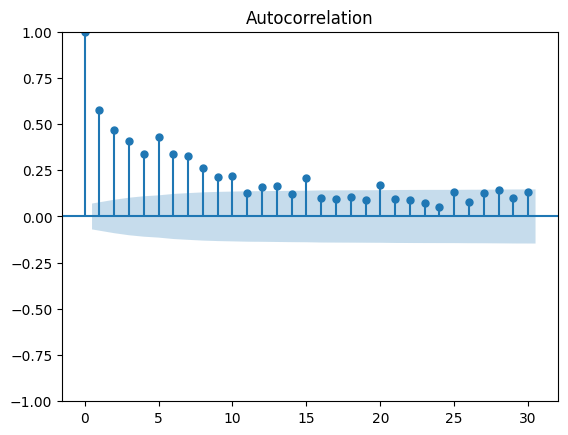

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(df['total_nb_um'], lags=30)
plt.show()

<Figure size 1000x500 with 0 Axes>

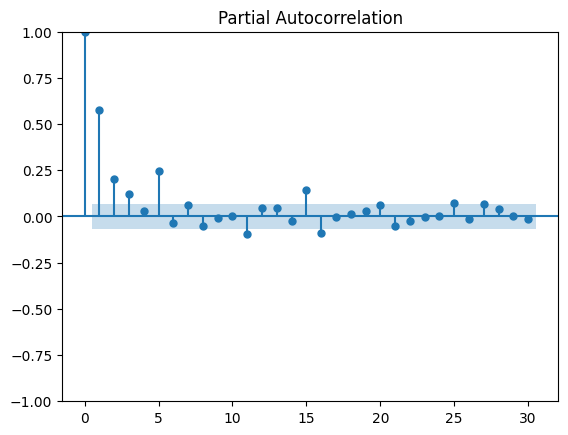

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_pacf(df['total_nb_um'], lags=30, method='ywm')
plt.show()


In [10]:
def layer1_baseline_recency_level(
    df_daily: pd.DataFrame,
    cutoff_date: pd.Timestamp,
    date_col="warehouse_day",
    y_col="total_nb_um",
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0,
    weekmask="Mon Tue Wed Thu Fri",
) -> pd.DataFrame:
    """
    Predicts a constant baseline for workdays only (Mon–Fri).
    Does NOT skip holidays (if a holiday is Mon–Fri, it stays in the forecast index).
    Horizons are calendar-day offsets, but outputs are filtered to Mon–Fri.
    """
    df = df_daily[[date_col, y_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    cutoff_date = pd.to_datetime(cutoff_date)
    hist = df[df[date_col] <= cutoff_date].copy()
    if len(hist) < 10:
        raise ValueError("Not enough history up to cutoff_date.")

    recent = hist.tail(lookback_days)

    age_days = (cutoff_date - recent[date_col]).dt.days.clip(lower=0).to_numpy()
    weights = 0.5 ** (age_days / half_life_days)
    base_value = float(np.average(recent[y_col].to_numpy(), weights=weights))

    future_dates = future_workdays_from_cutoff(cutoff_date, horizon_start, horizon_end, weekmask=weekmask)

    out = pd.DataFrame({date_col: future_dates})
    out["baseline_pred"] = base_value
    out["cutoff_date"] = cutoff_date
    return out


In [11]:
def fit_layer2A_multipliers(
    df_train: pd.DataFrame,
    train_start=None,
    date_col="warehouse_day",
    y_col="total_nb_um",
    lookback_days=90,
    half_life_days=30.0,
    ratio_clip=(0.2, 3.0),
    min_history=None,  # if None -> uses lookback_days
    weekmask="Mon Tue Wed Thu Fri",
) -> dict:
    """
    Learns robust multipliers using ratios actual/baseline from 1-step-ahead pseudo-forecasts (no leakage).
    Skips early dates until enough history is available for the baseline.
    """
    df = df_train[[date_col, y_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    if train_start is not None:
        df = df[df[date_col] >= pd.to_datetime(train_start)].reset_index(drop=True)

    if min_history is None:
        min_history = max(lookback_days, 10)

    rows = []
    eps = 1e-9

    for i in range(1, len(df)):
        # we are forecasting day i from cutoff day i-1
        cutoff = df.loc[i-1, date_col]
        day = df.loc[i, date_col]

        # history available up to cutoff (within df)
        hist = df[df[date_col] <= cutoff]
        if len(hist) < min_history:
            continue  # skip until baseline has enough history

        # baseline for H+1 only, Mon–Fri index
        base = layer1_baseline_recency_level(
            df_daily=df,                 # full df is OK; hist selection happens inside baseline
            cutoff_date=cutoff,
            date_col=date_col,
            y_col=y_col,
            horizon_start=1,
            horizon_end=1,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
            weekmask=weekmask
        )

        # base will output the next workday after cutoff. We want it to match `day`.
        # Because your dataset is Mon–Fri only, day should be the next row and also next workday.
        if base.empty or pd.to_datetime(base[date_col].iloc[0]) != day:
            continue

        base_pred = float(base["baseline_pred"].iloc[0])
        y_true = float(df.loc[i, y_col])

        ratio = (y_true / (base_pred + eps))
        ratio = float(np.clip(ratio, ratio_clip[0], ratio_clip[1]))

        rows.append((day, y_true, base_pred, ratio))

    ins = pd.DataFrame(rows, columns=[date_col, "y_true", "baseline_pred", "ratio"])
    if ins.empty:
        return {"multipliers": {
            "is_holiday": 1.0, "is_pre_holiday": 1.0, "is_post_holiday": 1.0, "iso_week": {}
        }}

    ins = add_calendar_features(ins, date_col=date_col)

    def rel_mult(flag):
        a = ins.loc[ins[flag], "ratio"]
        b = ins.loc[~ins[flag], "ratio"]
        if len(a) < 20 or len(b) < 20:
            return 1.0
        return float(a.median() / (b.median() + eps))

    mult = {
        "is_holiday": rel_mult("is_holiday"),
        "is_pre_holiday": rel_mult("is_pre_holiday"),
        "is_post_holiday": rel_mult("is_post_holiday"),
    }

    global_med = float(ins["ratio"].median())
    week_mult = {}
    for w, g in ins.groupby("iso_week"):
        week_mult[int(w)] = float(g["ratio"].median() / (global_med + eps)) if len(g) >= 10 else 1.0
    mult["iso_week"] = week_mult

    return {"multipliers": mult, "n_ratio_samples": len(ins)}


In [12]:
def predict_layer2A(
    df_train: pd.DataFrame,
    cutoff_date: pd.Timestamp,
    mult_pkg: dict,
    date_col="warehouse_day",
    y_col="total_nb_um",
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0
) -> pd.DataFrame:
    base = layer1_baseline_recency_level(
        df_daily=df_train,
        cutoff_date=cutoff_date,
        date_col=date_col,
        y_col=y_col,
        horizon_start=horizon_start,
        horizon_end=horizon_end,
        lookback_days=lookback_days,
        half_life_days=half_life_days
    )
    base = add_calendar_features(base, date_col=date_col)

    m = mult_pkg["multipliers"]

    factor = np.ones(len(base), dtype=float)
    for flag in ["is_holiday", "is_pre_holiday", "is_post_holiday"]:
        factor *= np.where(base[flag].to_numpy(), m.get(flag, 1.0), 1.0)

    # iso week factor
    week_map = m.get("iso_week", {})
    factor *= base["iso_week"].map(lambda w: week_map.get(int(w), 1.0)).to_numpy()

    out = base[[date_col, "baseline_pred"]].copy()
    out["factor_A"] = factor
    out["y_pred"] = out["baseline_pred"] * out["factor_A"]
    return out


In [13]:
def fit_layer2B_prophet(df_train: pd.DataFrame, date_col="warehouse_day", y_col="total_nb_um"):

    dfp = df_train[[date_col, y_col]].copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col])
    dfp = dfp.sort_values(date_col)

    dpp = dfp.rename(columns={date_col: "ds", y_col: "y"})[["ds", "y"]]

    # Add regressors (iso_week as categorical is tricky; we use year_end + holidays and yearly seasonality)
    feats = add_calendar_features(dfp.rename(columns={date_col: "warehouse_day"}), date_col="warehouse_day")
    #dpp["is_year_end"] = feats["is_year_end"].astype(int).values

    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.1
    )
    m.add_country_holidays(country_name="FR")
    #m.add_regressor("")
    m.fit(dpp)
    return m


In [14]:
def predict_layer2B_weighted_blend(
    df_train: pd.DataFrame,
    cutoff_date: pd.Timestamp,
    prophet_model,
    alpha: float = 0.2,   # 70% baseline, 30% prophet
    date_col="warehouse_day",
    y_col="total_nb_um",
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0
) -> pd.DataFrame:
    """
    Layer 2B using weighted blend:
    y_pred = alpha * baseline + (1-alpha) * prophet
    """

    # Baseline
    base = layer1_baseline_recency_level(
        df_daily=df_train,
        cutoff_date=cutoff_date,
        date_col=date_col,
        y_col=y_col,
        horizon_start=horizon_start,
        horizon_end=horizon_end,
        lookback_days=lookback_days,
        half_life_days=half_life_days
    )

    # Prophet forecast
    fut = pd.DataFrame({"ds": base[date_col]})
    tmp = add_calendar_features(base.rename(columns={date_col:"warehouse_day"}), date_col="warehouse_day")
    #fut["is_year_end"] = tmp["is_year_end"].astype(int).values

    fc = prophet_model.predict(fut)[["ds","yhat"]].rename(
        columns={"ds": date_col, "yhat": "prophet_yhat"}
    )

    out = base.merge(fc, on=date_col, how="left")

    out["y_pred"] = alpha * out["baseline_pred"] + (1 - alpha) * out["prophet_yhat"]
    #out["blend_alpha"] = alpha

    return out[[date_col, "baseline_pred", "prophet_yhat", "y_pred"]]


In [15]:
def predict_layer2B_ratio_clipping(
    df_train: pd.DataFrame,
    cutoff_date: pd.Timestamp,
    prophet_model,
    min_ratio: float = 0.1,
    max_ratio: float = 1.3,
    date_col="warehouse_day",
    y_col="total_nb_um",
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0
) -> pd.DataFrame:
    """
    Layer 2B using ratio clipping:
    y_pred = baseline * clip(prophet / baseline, min_ratio, max_ratio)
    """

    # Baseline
    base = layer1_baseline_recency_level(
        df_daily=df_train,
        cutoff_date=cutoff_date,
        date_col=date_col,
        y_col=y_col,
        horizon_start=horizon_start,
        horizon_end=horizon_end,
        lookback_days=lookback_days,
        half_life_days=half_life_days
    )

    # Prophet forecast
    fut = pd.DataFrame({"ds": base[date_col]})
    tmp = add_calendar_features(base.rename(columns={date_col:"warehouse_day"}), date_col="warehouse_day")
    #fut["is_year_end"] = tmp["is_year_end"].astype(int).values

    fc = prophet_model.predict(fut)[["ds","yhat"]].rename(
        columns={"ds": date_col, "yhat": "prophet_yhat"}
    )

    out = base.merge(fc, on=date_col, how="left")

    eps = 1e-9
    out["raw_ratio"] = out["prophet_yhat"] / (out["baseline_pred"] + eps)

    out["clipped_ratio"] = out["raw_ratio"].clip(lower=min_ratio, upper=max_ratio)

    out["y_pred"] = out["baseline_pred"] * out["clipped_ratio"]

    return out[[
        date_col,
        "baseline_pred",
        "prophet_yhat",
        "raw_ratio",
        "clipped_ratio",
        "y_pred"
    ]]


In [16]:
def weekly_metrics_table(pred_df: pd.DataFrame, date_col="warehouse_day", y_true_col="y_true", y_pred_col="y_pred"):
    dfp = pred_df.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col])

    iso = dfp[date_col].dt.isocalendar()
    dfp["iso_year"] = iso["year"].astype(int)
    dfp["iso_week"] = iso["week"].astype(int)

    wk = dfp.groupby(["iso_year","iso_week"], as_index=False).agg(
        week_start=(date_col, "min"),
        week_end=(date_col, "max"),
        y_true_sum=(y_true_col, "mean"),
        y_pred_sum=(y_pred_col, "mean"),
        n_days=(y_true_col, "size"),
    )

    wk["error"] = wk["y_pred_sum"] - wk["y_true_sum"]
    wk["abs_error"] = wk["error"].abs()

    eps = 1e-9
    wk["mape"] = wk["abs_error"] / (wk["y_true_sum"].abs() + eps)
    wk["smape"] = 2 * wk["abs_error"] / (wk["y_true_sum"].abs() + wk["y_pred_sum"].abs() + eps)

    wk["under_forecast"] = (wk["y_pred_sum"] < wk["y_true_sum"]).astype(int)  # 1 if under
    return wk.sort_values(["iso_year","iso_week"])


In [17]:
def rolling_backtest_layer12(
    df_model: pd.DataFrame,
    first_cutoff: str,
    last_cutoff: str,
    step_days: int = 7,
    horizon_start: int = 7,
    horizon_end: int = 28,
    lookback_days: int = 90,
    half_life_days: float = 30.0,
    weekmask: str = "Mon Tue Wed Thu Fri",
    # which models to run
    run_A: bool = True,
    run_B_weighted: bool = False,
    run_B_clipped: bool = True,
    # prophet params
    alpha: float = 0.2,
    min_ratio: float = 0.1,
    max_ratio: float = 1.3,
):
    """
    Rolling-origin backtest for H+7..H+28 on df_model only.

    Returns:
      predA_df: columns [cutoff_date, warehouse_day, y_true, y_pred] for Option A
      predBw_df: same for Prophet weighted blend (if enabled)
      predBc_df: same for Prophet ratio clipping (if enabled)
    """
    dfm = df_model.copy()
    dfm["warehouse_day"] = pd.to_datetime(dfm["warehouse_day"])
    dfm = dfm.sort_values("warehouse_day").reset_index(drop=True)

    first_cutoff = pd.to_datetime(first_cutoff)
    last_cutoff = pd.to_datetime(last_cutoff)

    preds_A, preds_Bw, preds_Bc = [], [], []

    cutoff = first_cutoff
    while cutoff <= last_cutoff:
        train_df = dfm[dfm["warehouse_day"] <= cutoff].copy()
        # Ground truth dates (Mon–Fri only, matching your data)
        truth_dates = future_workdays_from_cutoff(cutoff, horizon_start, horizon_end, weekmask=weekmask)
        test_df = dfm[dfm["warehouse_day"].isin(truth_dates)][["warehouse_day", "total_nb_um"]].rename(
            columns={"total_nb_um": "y_true"}
        )

        if len(train_df) < max(lookback_days + 30, 120) or test_df.empty:
            cutoff += pd.Timedelta(days=step_days)
            continue
        # -------- Option A: Multipliers --------
        if run_A:
            mult_pkg = fit_layer2A_multipliers(
                df_train=train_df,
                date_col="warehouse_day",
                y_col="total_nb_um",
                lookback_days=lookback_days,
                half_life_days=half_life_days
            )
            predA = predict_layer2A(
                df_train=train_df,
                cutoff_date=cutoff,
                mult_pkg=mult_pkg,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            predA = predA.merge(test_df, on="warehouse_day", how="inner")
            predA["cutoff_date"] = cutoff
            preds_A.append(predA[["cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        # Fit Prophet once per cutoff (so it's pure / non-leaky)
        prophet_model = None
        if run_B_weighted or run_B_clipped:
            prophet_model = fit_layer2B_prophet(train_df, date_col="warehouse_day", y_col="total_nb_um")

        # -------- Option B-weighted --------
        if run_B_weighted:
            predBw = predict_layer2B_weighted_blend(
                df_train=train_df,
                cutoff_date=cutoff,
                prophet_model=prophet_model,
                alpha=alpha,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            predBw = predBw.merge(test_df, on="warehouse_day", how="inner")
            predBw["cutoff_date"] = cutoff
            preds_Bw.append(predBw[["cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        # -------- Option B-clipped --------
        if run_B_clipped:
            predBc = predict_layer2B_ratio_clipping(
                df_train=train_df,
                cutoff_date=cutoff,
                prophet_model=prophet_model,
                min_ratio=min_ratio,
                max_ratio=max_ratio,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            predBc = predBc.merge(test_df, on="warehouse_day", how="inner")
            predBc["cutoff_date"] = cutoff
            preds_Bc.append(predBc[["cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        cutoff += pd.Timedelta(days=step_days)

    predA_df  = pd.concat(preds_A,  ignore_index=True) if preds_A  else pd.DataFrame()
    predBw_df = pd.concat(preds_Bw, ignore_index=True) if preds_Bw else pd.DataFrame()
    predBc_df = pd.concat(preds_Bc, ignore_index=True) if preds_Bc else pd.DataFrame()

    return predA_df, predBw_df, predBc_df


In [18]:
model_last_date = df_model["warehouse_day"].max()

# last cutoff must allow truth up to H+28 within df_model
last_cutoff = model_last_date - pd.Timedelta(days=28)

# first cutoff needs enough history for your baseline lookback
first_cutoff = df_model["warehouse_day"].min() + pd.Timedelta(days=240)

print("Backtest cutoffs:", first_cutoff.date(), "→", last_cutoff.date())


Backtest cutoffs: 2023-08-30 → 2025-12-02


In [81]:
predA_df, predBw_df, predBc_df = rolling_backtest_layer12(
    df_model=df_model,
    first_cutoff=str(first_cutoff.date()),
    last_cutoff=str(last_cutoff.date()),
    step_days=7,
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0,
    run_A=True,
    run_B_weighted=True,
    run_B_clipped=True,
    alpha=0.2,
    min_ratio=0.2,
    max_ratio=1.3
)

wkA  = weekly_metrics_table(predA_df)
wkBw = weekly_metrics_table(predBw_df) if not predBw_df.empty else None
wkBc = weekly_metrics_table(predBc_df) if not predBc_df.empty else None


/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_pre_holiday"] = (out[date_col] - timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_post_holiday"] = (out[date_col] + timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e

In [82]:
wkA  = weekly_metrics_table(predA_df)
wkBw = weekly_metrics_table(predBw_df) if not predBw_df.empty else None
wkBc = weekly_metrics_table(predBc_df) if not predBc_df.empty else None

In [19]:
def summarize_weekly(wk: pd.DataFrame, name: str):
    return pd.Series({
        "model": name,
        "median_abs_error": wk["abs_error"].median(),
        "p90_abs_error": wk["abs_error"].quantile(0.90),
        "median_mape": wk["mape"].median(),
        "p90_mape": wk["mape"].quantile(0.90),
        "median_smape": wk["smape"].median(),
        "under_forecast_rate": wk["under_forecast"].mean(),
        "bias_mean": wk["error"].mean(),
        "bias_median": wk["error"].median(),
        "error_std": wk["error"].std(),
    })

summary = pd.DataFrame([
    summarize_weekly(wkA, "Option A (Multipliers)"),
    summarize_weekly(wkBw, "Option B (Prophet)"),
    summarize_weekly(wkBc, "Option B (Prophet)")

])

summary

NameError: name 'wkA' is not defined

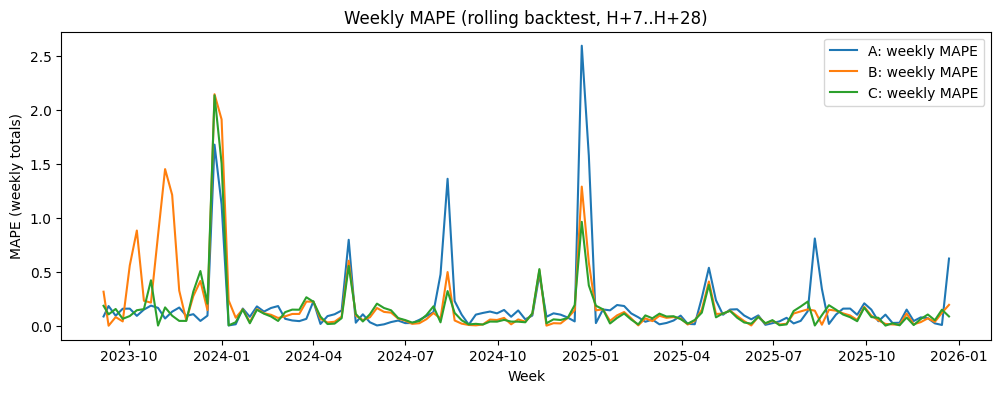

In [84]:
plt.figure(figsize=(12,4))
plt.plot(wkA["week_start"], wkA["mape"], label="A: weekly MAPE")
plt.plot(wkBw["week_start"], wkBw["mape"], label="B: weekly MAPE")
plt.plot(wkBc["week_start"], wkBc["mape"], label="C: weekly MAPE")

plt.title("Weekly MAPE (rolling backtest, H+7..H+28)")
plt.xlabel("Week")
plt.ylabel("MAPE (weekly totals)")
plt.legend()
plt.show()


In [20]:
def rolling_backtest_layer12_stacked(
    df_model: pd.DataFrame,
    first_cutoff: str,
    last_cutoff: str,
    step_days: int = 7,
    horizon_start: int = 7,
    horizon_end: int = 28,
    lookback_days: int = 90,
    half_life_days: float = 30.0,
    weekmask: str = "Mon Tue Wed Thu Fri",
    # which models to run
    run_A: bool = True,
    run_B_weighted: bool = True,
    run_B_clipped: bool = True,
    # prophet params
    alpha: float = 0.1,
    min_ratio: float = 0.1,
    max_ratio: float = 1,
):
    """
    Returns ONE stacked dataframe with columns:
      [model, cutoff_date, warehouse_day, y_true, y_pred]
    """
    dfm = df_model.copy()
    dfm["warehouse_day"] = pd.to_datetime(dfm["warehouse_day"])
    dfm = dfm.sort_values("warehouse_day").reset_index(drop=True)

    first_cutoff = pd.to_datetime(first_cutoff)
    last_cutoff = pd.to_datetime(last_cutoff)

    all_preds = []

    cutoff = first_cutoff
    while cutoff <= last_cutoff:
        train_df = dfm[dfm["warehouse_day"] <= cutoff].copy()

        truth_dates = future_workdays_from_cutoff(cutoff, horizon_start, horizon_end, weekmask=weekmask)
        test_df = dfm[dfm["warehouse_day"].isin(truth_dates)][["warehouse_day", "total_nb_um"]].rename(
            columns={"total_nb_um": "y_true"}
        )

        if len(train_df) < max(lookback_days + 30, 120) or test_df.empty:
            cutoff += pd.Timedelta(days=step_days)
            continue

        # --- Option A (multipliers) ---
        if run_A:
            mult_pkg = fit_layer2A_multipliers(
                df_train=train_df,
                date_col="warehouse_day",
                y_col="total_nb_um",
                lookback_days=lookback_days,
                half_life_days=half_life_days
            )
            pred = predict_layer2A(
                df_train=train_df,
                cutoff_date=cutoff,
                mult_pkg=mult_pkg,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            pred = pred.merge(test_df, on="warehouse_day", how="inner")
            pred["cutoff_date"] = cutoff
            pred["model"] = "A_multipliers"
            all_preds.append(pred[["model", "cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        # Fit Prophet once per cutoff if needed
        prophet_model = None
        if run_B_weighted or run_B_clipped:
            prophet_model = fit_layer2B_prophet(train_df, date_col="warehouse_day", y_col="total_nb_um")

        # --- Option B (weighted blend) ---
        if run_B_weighted:
            pred = predict_layer2B_weighted_blend(
                df_train=train_df,
                cutoff_date=cutoff,
                prophet_model=prophet_model,
                alpha=alpha,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            pred = pred.merge(test_df, on="warehouse_day", how="inner")
            pred["cutoff_date"] = cutoff
            pred["model"] = f"B_weighted_alpha={alpha:.2f}"
            all_preds.append(pred[["model", "cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        # --- Option B (ratio clipping) ---
        if run_B_clipped:
            pred = predict_layer2B_ratio_clipping(
                df_train=train_df,
                cutoff_date=cutoff,
                prophet_model=prophet_model,
                min_ratio=min_ratio,
                max_ratio=max_ratio,
                date_col="warehouse_day",
                y_col="total_nb_um",
                horizon_start=horizon_start,
                horizon_end=horizon_end,
                lookback_days=lookback_days,
                half_life_days=half_life_days
            ).rename(columns={"y_pred": "y_pred"})
            pred = pred.merge(test_df, on="warehouse_day", how="inner")
            pred["cutoff_date"] = cutoff
            pred["model"] = f"B_clipped_{min_ratio:.2f}-{max_ratio:.2f}"
            all_preds.append(pred[["model", "cutoff_date", "warehouse_day", "y_true", "y_pred"]])

        cutoff += pd.Timedelta(days=step_days)

    return pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()


In [21]:
def weekly_metrics_table_stacked(pred_df: pd.DataFrame,
                                 date_col="warehouse_day",
                                 y_true_col="y_true",
                                 y_pred_col="y_pred") -> pd.DataFrame:
    """
    Takes stacked daily predictions with a 'model' column and returns weekly metrics per model.
    Weekly totals are sums across Mon–Fri days.
    """
    if pred_df.empty:
        return pd.DataFrame()

    dfp = pred_df.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col])

    iso = dfp[date_col].dt.isocalendar()
    dfp["iso_year"] = iso["year"].astype(int)
    dfp["iso_week"] = iso["week"].astype(int)

    wk = dfp.groupby(["model", "iso_year", "iso_week"], as_index=False).agg(
        week_start=(date_col, "min"),
        week_end=(date_col, "max"),
        y_true_sum=(y_true_col, "mean"),
        y_pred_sum=(y_pred_col, "mean"),
        n_days=(y_true_col, "size"),
    )

    wk["error"] = wk["y_pred_sum"] - wk["y_true_sum"]
    wk["abs_error"] = wk["error"].abs()

    eps = 1e-9
    wk["mape"] = wk["abs_error"] / (wk["y_true_sum"].abs() + eps)
    wk["smape"] = 2 * wk["abs_error"] / (wk["y_true_sum"].abs() + wk["y_pred_sum"].abs() + eps)

    wk["under_forecast"] = (wk["y_pred_sum"] < wk["y_true_sum"]).astype(int)

    return wk.sort_values(["model", "iso_year", "iso_week"])


In [22]:
def summarize_weekly_by_model(wk: pd.DataFrame) -> pd.DataFrame:
    if wk.empty:
        return pd.DataFrame()

    def _summ(g):
        return pd.Series({
            "median_abs_error": g["abs_error"].median(),
            "p90_abs_error": g["abs_error"].quantile(0.90),
            "median_mape": g["mape"].mean(),
            "p90_mape": g["mape"].quantile(0.90),
            "median_smape": g["smape"].mean(),
            "under_forecast_rate": g["under_forecast"].mean(),
            "bias_mean": g["error"].mean(),
            "bias_median": g["error"].median(),
            "error_std": g["error"].std(),
            "n_weeks": len(g),
        })

    return wk.groupby("model", as_index=False).apply(_summ).reset_index(drop=True)


In [88]:
model_last_date = df_model["warehouse_day"].max()
last_cutoff = model_last_date - pd.Timedelta(days=28)
first_cutoff = df_model["warehouse_day"].min() + pd.Timedelta(days=180)

pred_stacked = rolling_backtest_layer12_stacked(
    df_model=df_model,
    first_cutoff=str(first_cutoff.date()),
    last_cutoff=str(last_cutoff.date()),
    step_days=7,
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0,
    run_A=True,
    run_B_weighted=True,
    run_B_clipped=True,
    alpha=0.1,
    min_ratio=0.1,
    max_ratio=1.5
)

wk = weekly_metrics_table_stacked(pred_stacked)
summary = summarize_weekly_by_model(wk)

summary


/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_pre_holiday"] = (out[date_col] - timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_post_holiday"] = (out[date_col] + timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_14283/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e

,model,median_abs_error,p90_abs_error,median_mape,p90_mape,median_smape,under_forecast_rate,bias_mean,bias_median,error_std,n_weeks
0,A_multipliers,237.429201,639.179464,0.199596,0.367210,0.158590,0.565891,46.429056,-38.115215,457.775276,129.0
1,B_clipped_0.10-1.50,223.283299,913.795964,0.192743,0.432443,0.162511,0.465116,150.863332,56.958855,546.138341,129.0
2,B_weighted_alpha=0.10,234.161365,1550.725593,0.241213,0.662435,0.188067,0.418605,283.216879,62.724121,768.362798,129.0


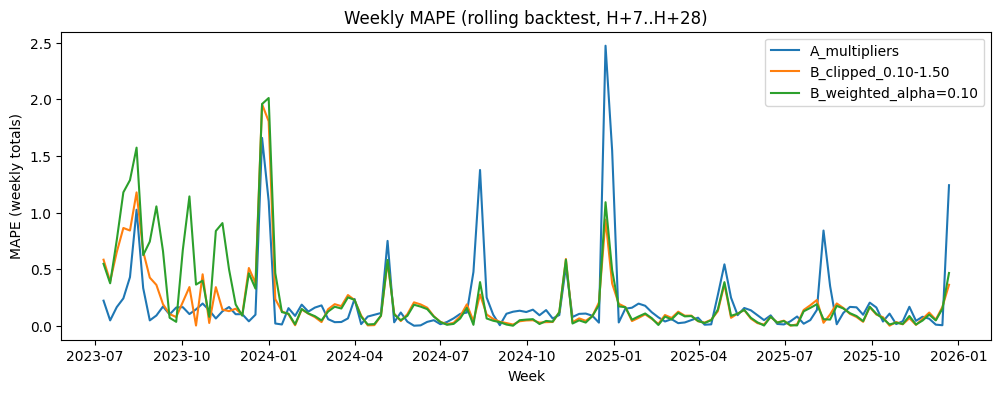

In [89]:
plt.figure(figsize=(12,4))
for m, g in wk.groupby("model"):
    plt.plot(g["week_start"], g["mape"], label=m)
plt.title("Weekly MAPE (rolling backtest, H+7..H+28)")
plt.xlabel("Week")
plt.ylabel("MAPE (weekly totals)")
plt.legend()
plt.show()


In [90]:
wk.model.unique()

array(['A_multipliers', 'B_clipped_0.10-1.50', 'B_weighted_alpha=0.10'],
      dtype=object)

In [91]:
import matplotlib.pyplot as plt

def plot_daily_real_vs_pred(pred_df, model_name):
    df = pred_df[pred_df["model"] == model_name].copy()
    df = df.sort_values("warehouse_day")

    plt.figure(figsize=(14,5))
    plt.plot(df["warehouse_day"], df["y_true"], label="Actual", color="blue", linewidth=2, alpha=0.6)
    plt.plot(df["warehouse_day"], df["y_pred"], label="Predicted", color="green", alpha=0.6)

    plt.title(f"Daily Volume — Actual vs Predicted")
    plt.xlabel("Date")
    plt.ylabel("Units")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


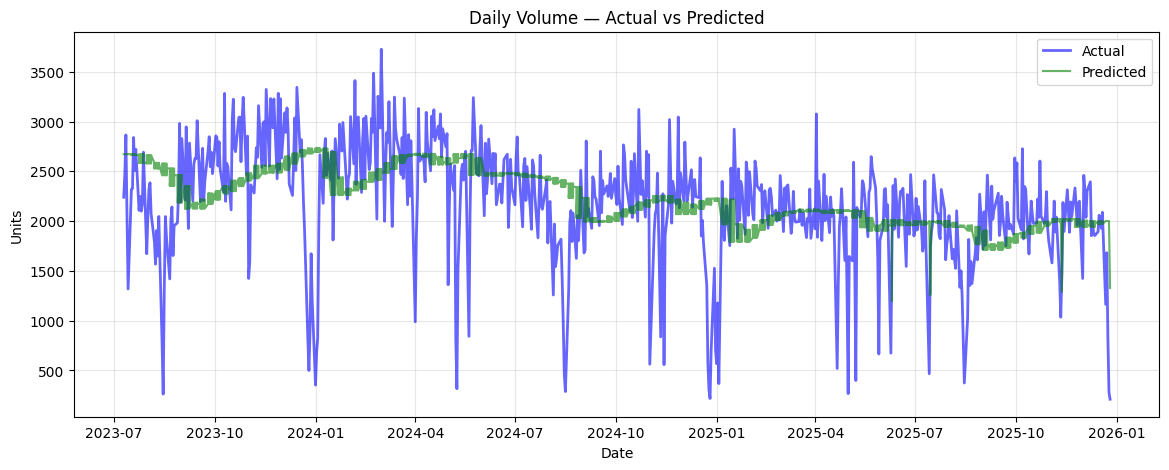

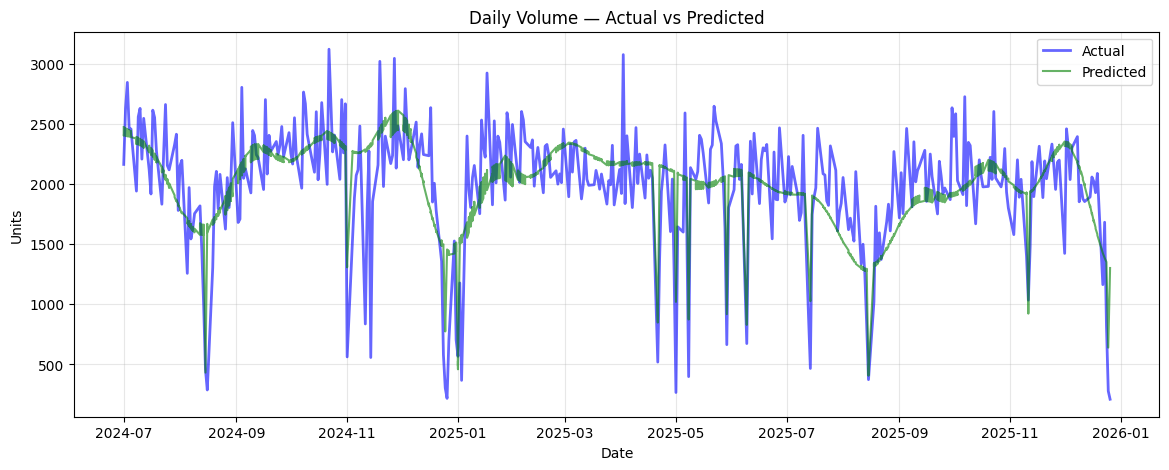

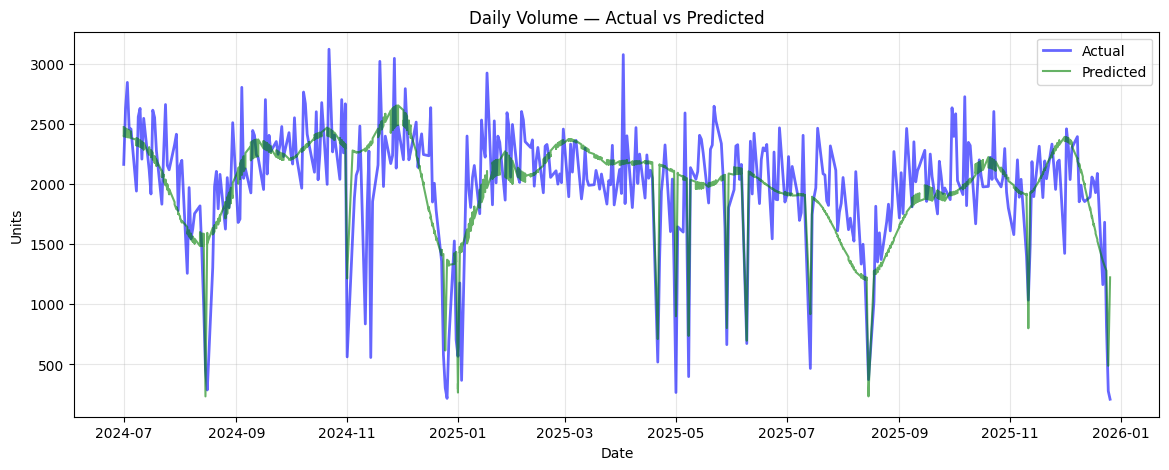

In [92]:
plot_daily_real_vs_pred(pred_stacked, "A_multipliers")
plot_daily_real_vs_pred(pred_stacked[pred_stacked['warehouse_day']>=pd.Timestamp("2024-07-01")], "B_weighted_alpha=0.10")
plot_daily_real_vs_pred(pred_stacked[pred_stacked['warehouse_day']>=pd.Timestamp("2024-07-01")], "B_clipped_0.10-1.50")

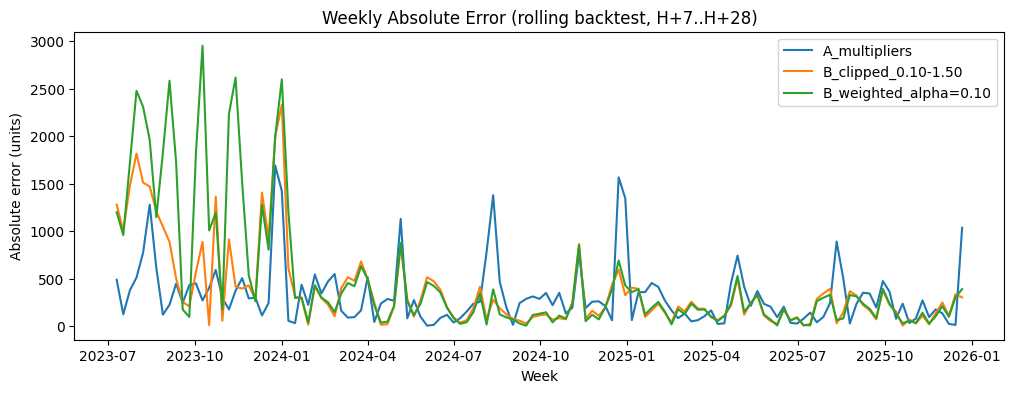

In [93]:
plt.figure(figsize=(12,4))
for m, g in wk.groupby("model"):
    plt.plot(g["week_start"], g["abs_error"], label=m)
plt.title("Weekly Absolute Error (rolling backtest, H+7..H+28)")
plt.xlabel("Week")
plt.ylabel("Absolute error (units)")
plt.legend()
plt.show()


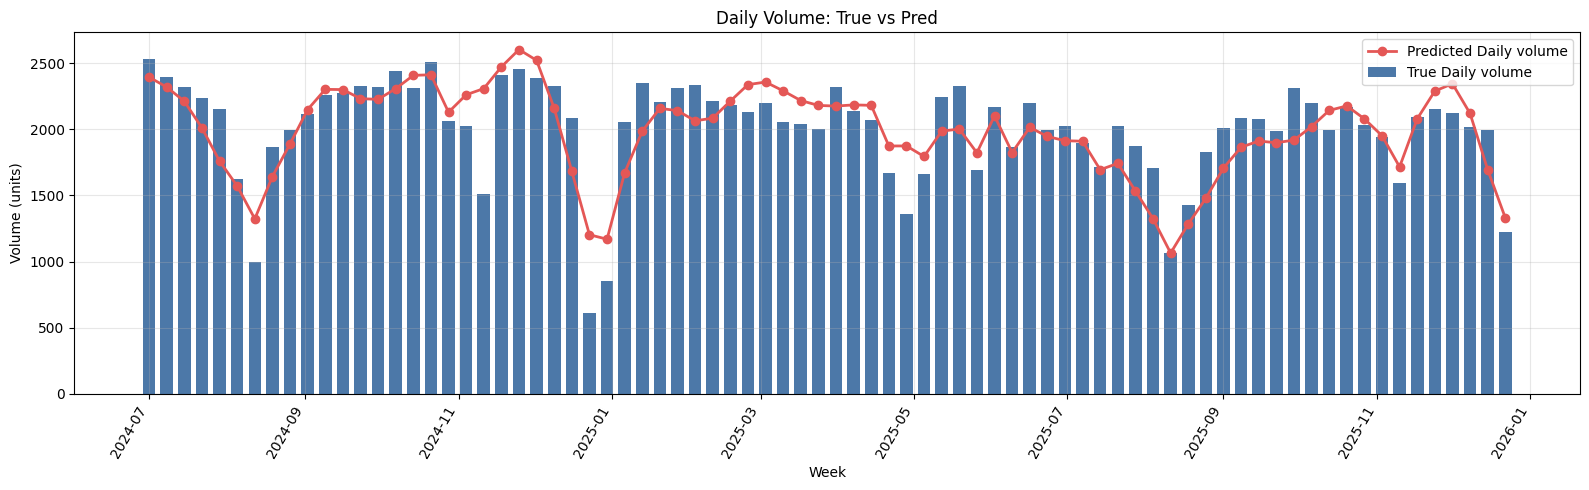

In [94]:
import matplotlib.pyplot as plt
import pandas as pd

wk2 = wkBc.copy()
wk2["week"] = pd.to_datetime(wk2["week_start"])
wk2 = wk2[wk2["week"]>=pd.Timestamp("2024-07-01")]
plt.figure(figsize=(16,5))

# Bars = true values
plt.bar(
    wk2["week"],
    wk2["y_true_sum"],
    width=5,                      # makes weekly bars look continuous
    label="True Daily volume",
    color="#4C78A8"
)

# Line = predicted values
plt.plot(
    wk2["week"],
    wk2["y_pred_sum"],
    label="Predicted Daily volume",
    color="#E45756",
    linewidth=2,
    marker="o"
)

plt.title("Daily Volume: True vs Pred")
plt.xlabel("Week")
plt.ylabel("Volume (units)")
plt.xticks(rotation=60, ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

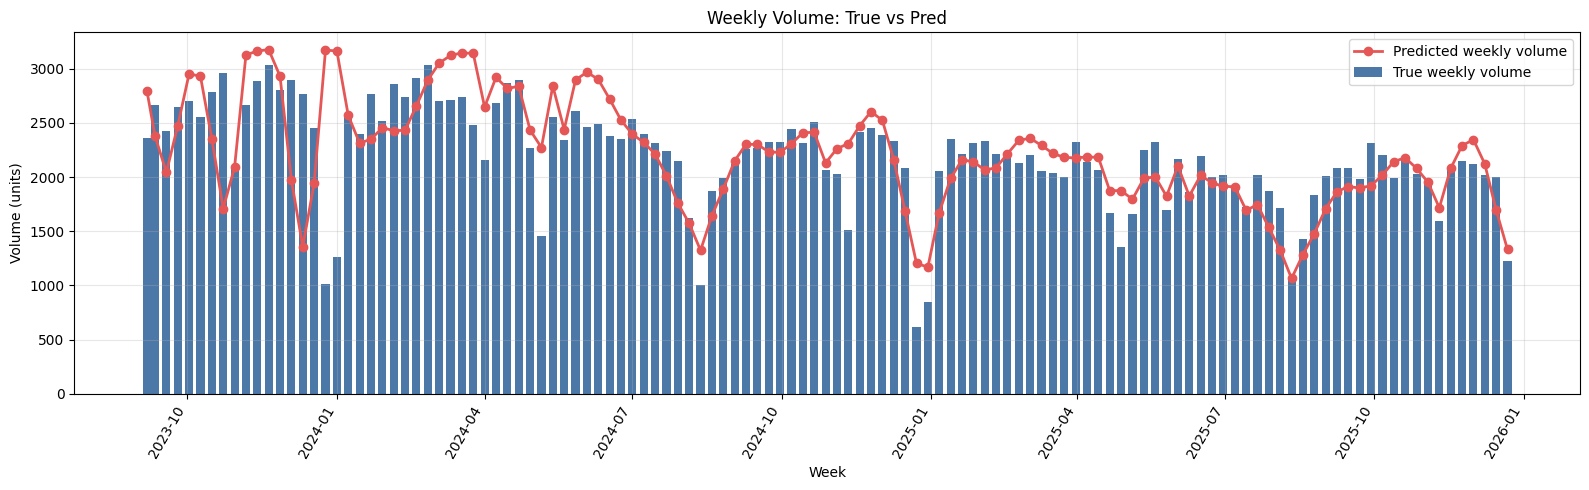

In [95]:

import matplotlib.pyplot as plt
import pandas as pd

wk2 = wkBc.copy()
wk2["week"] = pd.to_datetime(wk2["week_start"])

plt.figure(figsize=(16,5))

# Bars = true values
plt.bar(
    wk2["week"],
    wk2["y_true_sum"],
    width=5,                      # makes weekly bars look continuous
    label="True weekly volume",
    color="#4C78A8"
)

# Line = predicted values
plt.plot(
    wk2["week"],
    wk2["y_pred_sum"],
    label="Predicted weekly volume",
    color="#E45756",
    linewidth=2,
    marker="o"
)

plt.title("Weekly Volume: True vs Pred")
plt.xlabel("Week")
plt.ylabel("Volume (units)")
plt.xticks(rotation=60, ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# =========================
# CONFIGURATION
# =========================
ROLLING_WINDOW_WEEKS = 6        # window for CV
THRESHOLD_METHOD = "percentile"  # "percentile" | "median" | "fixed"
PERCENTILE = 0.75                 # 0.5 = median; try 0.4 or 0.6 to tune split
FIXED_THRESHOLD = 0.15           # only used if THRESHOLD_METHOD == "fixed"

# =========================
# PREP
# =========================
df = wkBc[wkBc["week_start"]>=pd.Timestamp("2024-09-01")].copy()

# Parse dates if needed and sort in chronological order
if not np.issubdtype(df['week_start'].dtype, np.datetime64):
    df['week_start'] = pd.to_datetime(df['week_start'])
if not np.issubdtype(df['week_end'].dtype, np.datetime64):
    df['week_end'] = pd.to_datetime(df['week_end'])

sort_cols = ['iso_year', 'iso_week'] if {'iso_year','iso_week'}.issubset(df.columns) else ['week_start']
df = df.sort_values(sort_cols).reset_index(drop=True)

# Rename for clarity (means, not sums)
df = df.rename(columns={'y_true_sum': 'y_true_mean', 'y_pred_sum': 'y_pred_mean'})

# =========================
# VOLATILITY VIA ROLLING CV ON y_true_mean
# =========================
rolling_mean = df['y_true_mean'].rolling(window=ROLLING_WINDOW_WEEKS, min_periods=ROLLING_WINDOW_WEEKS, center=True).mean()
rolling_std  = df['y_true_mean'].rolling(window=ROLLING_WINDOW_WEEKS, min_periods=ROLLING_WINDOW_WEEKS, center=True).std()
df['cv'] = rolling_std / rolling_mean

# Threshold for stable vs volatile
if THRESHOLD_METHOD == "percentile":
    thr = np.nanquantile(df['cv'], PERCENTILE)
elif THRESHOLD_METHOD == "median":
    thr = np.nanmedian(df['cv'])
elif THRESHOLD_METHOD == "fixed":
    thr = FIXED_THRESHOLD
else:
    raise ValueError("THRESHOLD_METHOD must be one of: 'percentile', 'median', 'fixed'.")

df['regime'] = np.where(df['cv'] <= thr, 'stable', 'volatile')

# =========================
# ERROR METRICS (based on weekly means)
# =========================
df['se'] = abs(df['y_pred_mean'] - df['y_true_mean'])
true_safe = df['y_true_mean'].replace(0, np.nan)  # avoid divide-by-zero in MAPE
df['ape'] = np.abs(df['y_pred_mean'] - df['y_true_mean']) / true_safe  # NaN where y_true_mean==0

# =========================
# REGIME-LEVEL SUMMARY
# =========================
regime_summary = (
    df.groupby('regime')
      .agg(
          n_weeks=('regime', 'size'),
          MSE=('se', 'mean'),
          MAPE=('ape', 'mean')
      )
      .reset_index()
)
regime_summary['MAPE_pct'] = regime_summary['MAPE'] * 100

# =========================
# CONTIGUOUS PERIOD SUMMARY (optional)
# =========================
df['regime_block_id'] = (df['regime'] != df['regime'].shift(1)).cumsum()
block_summary = (
    df.groupby(['regime_block_id', 'regime'])
      .agg(
          period_start=('week_start', 'min'),
          period_end=('week_end', 'max'),
          n_weeks=('regime', 'size'),
          MSE=('se', 'mean'),
          MAPE=('ape', 'mean')
      )
      .reset_index()
      .sort_values('period_start')
)
block_summary['MAPE_pct'] = block_summary['MAPE'] * 100

# =========================
# OUTPUT
# =========================
print("\n=== Regime-level summary (stable vs volatile) ===")
print(regime_summary[['regime','n_weeks','MSE','MAPE','MAPE_pct']])

print("\n=== Contiguous period summary (each stable/volatile block) ===")
print(block_summary[['regime','period_start','period_end','n_weeks','MSE','MAPE','MAPE_pct']])



=== Regime-level summary (stable vs volatile) ===
     regime  n_weeks         MSE      MAPE   MAPE_pct
0    stable       48  152.192090  0.077998   7.799778
1  volatile       21  239.659047  0.163939  16.393929

=== Contiguous period summary (each stable/volatile block) ===
     regime period_start period_end  n_weeks         MSE      MAPE   MAPE_pct
0  volatile   2024-09-02 2024-09-20        3   34.244477  0.015424   1.542398
1    stable   2024-09-23 2024-12-06       11  177.889014  0.093916   9.391646
2  volatile   2024-12-09 2025-01-24        7  325.818398  0.281543  28.154283
3    stable   2025-01-27 2025-05-02       14  184.455415  0.097380   9.737959
4  volatile   2025-05-05 2025-05-23        3  239.060364  0.111644  11.164362
5    stable   2025-05-26 2025-07-25        9   99.289063  0.049910   4.990970
6  volatile   2025-07-28 2025-09-05        6  254.014238  0.142043  14.204261
7    stable   2025-09-08 2025-12-12       14  133.747414  0.064165   6.416505
8  volatile   2025-12

In [97]:
df2 = wkBc[wkBc["week_start"]>=pd.Timestamp("2025-10-01")].copy()

In [98]:
df2.mape.mean()

np.float64(0.06148342831631635)

In [27]:
STRUCT_METHOD = "B_prophet_clipped"        # "A_multipliers" | "B_prophet_clipped" | "B_prophet_weighted"

# Only used if Prophet method chosen:
PROPHET_ALPHA = 0.1                  # for weighted blend
CLIP_MIN_RATIO = 0.1                 # for ratio clipping
CLIP_MAX_RATIO = 1.8

L3_START_DATE = pd.Timestamp("2024-07-01")


In [28]:
def compute_recent_stats_scalar(df_hist: pd.DataFrame, y_col="total_nb_um", windows=(10, 20, 30)):
    y = df_hist[y_col].astype(float)
    feats = {}
    for w in windows:
        if len(y) >= w:
            m = y.tail(w).mean()
            s = y.tail(w).std(ddof=0)
        else:
            m = y.mean()
            s = y.std(ddof=0)
        feats[f"mean_{w}"] = float(m)
        feats[f"std_{w}"] = float(s)
        feats[f"cv_{w}"] = float(s / (m + 1e-9))
    return feats


def days_to_nearest_holiday(dates: pd.Series):
    import holidays
    fr_holidays = holidays.France()

    dates = pd.to_datetime(dates)
    hol = pd.to_datetime(sorted(list(fr_holidays.keys())))
    if len(hol) == 0:
        return pd.Series(0, index=dates.index), pd.Series(0, index=dates.index)

    hol_np = hol.values.astype("datetime64[D]")
    d_np = dates.values.astype("datetime64[D]")

    idx_next = np.searchsorted(hol_np, d_np, side="left")
    idx_prev = idx_next - 1

    next_h = np.where(idx_next < len(hol_np), hol_np[idx_next], hol_np[-1])
    prev_h = np.where(idx_prev >= 0, hol_np[idx_prev], hol_np[0])

    days_to_next = (next_h - d_np).astype("timedelta64[D]").astype(int)
    days_since_prev = (d_np - prev_h).astype("timedelta64[D]").astype(int)

    return pd.Series(days_to_next, index=dates.index), pd.Series(days_since_prev, index=dates.index)


In [29]:
def structural_forecast(
    df_train: pd.DataFrame,
    cutoff_date: pd.Timestamp,
    method: str,
    horizon_start=7,
    horizon_end=28,
    lookback_days=90,
    half_life_days=30.0,
    weekmask="Mon Tue Wed Thu Fri",
    alpha=0.7,
    min_ratio=0.75,
    max_ratio=1.25,
    date_col="warehouse_day",
    y_col="total_nb_um",
) -> pd.DataFrame:
    if method == "A_multipliers":
        mult_pkg = fit_layer2A_multipliers(
            df_train=df_train,
            date_col=date_col,
            y_col=y_col,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
            weekmask=weekmask,
        )
        pred = predict_layer2A(
            df_train=df_train,
            cutoff_date=cutoff_date,
            mult_pkg=mult_pkg,
            date_col=date_col,
            y_col=y_col,
            horizon_start=horizon_start,
            horizon_end=horizon_end,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
        )
        return pred[[date_col, "baseline_pred"]].assign(y_struct=pred["y_pred"])

    if method == "B_prophet_weighted":
        pm = fit_layer2B_prophet(df_train, date_col=date_col, y_col=y_col)
        pred = predict_layer2B_weighted_blend(
            df_train=df_train,
            cutoff_date=cutoff_date,
            prophet_model=pm,
            alpha=alpha,
            date_col=date_col,
            y_col=y_col,
            horizon_start=horizon_start,
            horizon_end=horizon_end,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
        )
        out = pred[[date_col, "baseline_pred", "prophet_yhat"]].assign(y_struct=pred["y_pred"])
        return out

    if method == "B_prophet_clipped":
        pm = fit_layer2B_prophet(df_train, date_col=date_col, y_col=y_col)
        pred = predict_layer2B_ratio_clipping(
            df_train=df_train,
            cutoff_date=cutoff_date,
            prophet_model=pm,
            min_ratio=min_ratio,
            max_ratio=max_ratio,
            date_col=date_col,
            y_col=y_col,
            horizon_start=horizon_start,
            horizon_end=horizon_end,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
        )
        out = pred[[date_col, "baseline_pred", "prophet_yhat", "raw_ratio", "clipped_ratio"]].assign(y_struct=pred["y_pred"])
        return out

    raise ValueError(f"Unknown method: {method}")


In [30]:
def build_layer3_dataset_h7_h28(
    df_model: pd.DataFrame,
    structural_method: str,
    first_cutoff: str,
    last_cutoff: str,
    step_days: int = 7,
    horizon_start: int = 7,
    horizon_end: int = 28,
    lookback_days: int = 90,
    half_life_days: float = 30.0,
    weekmask: str = "Mon Tue Wed Thu Fri",
    alpha: float = 0.7,
    min_ratio: float = 0.75,
    max_ratio: float = 1.25,
    date_col: str = "warehouse_day",
    y_col: str = "total_nb_um",
    min_history: int = 120,
) -> pd.DataFrame:

    df = df_model[[date_col, y_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    first_cutoff = pd.to_datetime(first_cutoff)
    last_cutoff = pd.to_datetime(last_cutoff)

    rows = []
    cutoff = first_cutoff
    eps = 1e-9

    while cutoff <= last_cutoff:
        hist = df[df[date_col] <= cutoff].copy()
        if len(hist) < min_history:
            cutoff += pd.Timedelta(days=step_days)
            continue

        # Structural forecast S(d) for future workdays in H+7..H+28
        struct = structural_forecast(
            df_train=hist,
            cutoff_date=cutoff,
            method=structural_method,
            horizon_start=horizon_start,
            horizon_end=horizon_end,
            lookback_days=lookback_days,
            half_life_days=half_life_days,
            weekmask=weekmask,
            alpha=alpha,
            min_ratio=min_ratio,
            max_ratio=max_ratio,
            date_col=date_col,
            y_col=y_col,
        )

        # Ground truth on same workday set
        truth_dates = future_workdays_from_cutoff(cutoff, horizon_start, horizon_end, weekmask=weekmask)
        truth = df[df[date_col].isin(truth_dates)][[date_col, y_col]].rename(columns={y_col: "y_true"})

        merged = struct.merge(truth, on=date_col, how="inner")
        if merged.empty:
            cutoff += pd.Timedelta(days=step_days)
            continue

        # Features for target date (known in advance)
        merged = add_calendar_features(merged, date_col=date_col)
        merged["horizon"] = (merged[date_col] - cutoff).dt.days.astype(int)
        
        dtn, dsp = days_to_nearest_holiday(merged[date_col])
        merged["days_to_next_holiday"] = dtn.values
        merged["days_since_prev_holiday"] = dsp.values

        # Regime features from history <= cutoff
        stats = compute_recent_stats_scalar(hist, y_col=y_col, windows=(10, 20, 30))
        for k, v in stats.items():
            merged[k] = v

        # Target for L3
        merged = merged[(merged["y_struct"] > 0) & (merged["y_true"] > 0)].copy()
        merged["target_log_ratio"] = np.log(merged["y_true"] / (merged["y_struct"] + eps))
        #merged["target_log_ratio"] = (merged["y_true"] / (merged["y_struct"]))


        merged["cutoff_date"] = cutoff

        rows.append(merged)

        cutoff += pd.Timedelta(days=step_days)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


In [31]:
model_last = df_model["warehouse_day"].max()
last_cutoff = model_last - pd.Timedelta(days=28)
first_cutoff = df_model["warehouse_day"].min() + pd.Timedelta(days=150)

train_l3 = build_layer3_dataset_h7_h28(
    df_model=df_model,
    structural_method=STRUCT_METHOD,
    first_cutoff=str(first_cutoff.date()),
    last_cutoff=str(last_cutoff.date()),
    step_days=7,
    horizon_start=7,
    horizon_end=28,
    lookback_days=30,
    half_life_days=10,
    weekmask="Mon Tue Wed Thu Fri",
    alpha=PROPHET_ALPHA,
    min_ratio=CLIP_MIN_RATIO,
    max_ratio=CLIP_MAX_RATIO,
)

train_l3.shape, train_l3.columns


/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_11880/3543147469.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_pre_holiday"] = (out[date_col] - timedelta(days=1)).isin(fr_holidays)
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_11880/3543147469.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  out["is_post_holiday"] = (out[date_col] + timedelta(days=1)).isin(fr_holidays)
17:24:39 - cmdstanpy - INFO - Chain [1] start processing
17:24:39 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykern

((2048, 27),
 Index(['warehouse_day', 'baseline_pred', 'prophet_yhat', 'raw_ratio',
        'clipped_ratio', 'y_struct', 'y_true', 'is_holiday', 'is_pre_holiday',
        'is_post_holiday', 'iso_year', 'iso_week', 'month', 'horizon',
        'days_to_next_holiday', 'days_since_prev_holiday', 'mean_10', 'std_10',
        'cv_10', 'mean_20', 'std_20', 'cv_20', 'mean_30', 'std_30', 'cv_30',
        'target_log_ratio', 'cutoff_date'],
       dtype='object'))

In [32]:
train_l3["horizon"].value_counts().sort_index()

horizon
7     128
8     128
11    128
12    128
13    128
14    128
15    128
18    128
19    128
20    128
21    128
22    128
25    128
26    128
27    128
28    128
Name: count, dtype: int64

In [33]:
train_l3["target_log_ratio"].describe()

count    2048.000000
mean       -0.045728
std         0.455049
min        -2.844051
25%        -0.171860
50%        -0.025955
75%         0.124642
max         2.554547
Name: target_log_ratio, dtype: float64

In [34]:
train_l3["cutoff_date"] = pd.to_datetime(train_l3["cutoff_date"])
train_l3 = train_l3[train_l3["cutoff_date"] >= L3_START_DATE].copy()

cutoffs_sorted = np.sort(train_l3["cutoff_date"].unique())

n_val = min(10, max(2, int(len(cutoffs_sorted) * 0.2)))
val_cutoffs = set(cutoffs_sorted[-n_val:])

l3_train = train_l3[~train_l3["cutoff_date"].isin(val_cutoffs)].copy()
l3_val   = train_l3[ train_l3["cutoff_date"].isin(val_cutoffs)].copy()

len(l3_train), len(l3_val), (min(val_cutoffs), max(val_cutoffs))

(1024,
 160,
 (np.datetime64('2025-09-25T00:00:00.000000000'),
  np.datetime64('2025-11-27T00:00:00.000000000')))

In [35]:
l3_train["residu"] = (l3_train['y_true'] - l3_train['y_struct'])
hsample = l3_train[l3_train['horizon']<=12]

In [36]:
hsample

,warehouse_day,baseline_pred,prophet_yhat,raw_ratio,clipped_ratio,y_struct,y_true,is_holiday,is_pre_holiday,is_post_holiday,...,cv_10,mean_20,std_20,cv_20,mean_30,std_30,cv_30,target_log_ratio,cutoff_date,residu
864,2024-07-11,2462.585413,2362.792766,0.959476,0.959476,2362.792766,2208.0,False,False,False,...,0.107841,2454.60,237.139917,0.096610,2499.433333,278.086639,0.111260,-0.067757,2024-07-04,-154.792766
865,2024-07-12,2462.585413,2350.915176,0.954653,0.954653,2350.915176,2547.0,False,False,False,...,0.107841,2454.60,237.139917,0.096610,2499.433333,278.086639,0.111260,0.080112,2024-07-04,196.084824
866,2024-07-15,2462.585413,2301.620035,0.934636,0.934636,2301.620035,2121.0,False,True,False,...,0.107841,2454.60,237.139917,0.096610,2499.433333,278.086639,0.111260,-0.081726,2024-07-04,-180.620035
867,2024-07-16,2462.585413,2280.330807,0.925991,0.925991,2280.330807,1918.0,False,False,False,...,0.107841,2454.60,237.139917,0.096610,2499.433333,278.086639,0.111260,-0.173038,2024-07-04,-362.330807
880,2024-07-18,2416.648759,2224.738220,0.920588,0.920588,2224.738220,2554.0,False,False,False,...,0.104134,2390.30,240.652467,0.100679,2446.133333,261.097776,0.106739,0.138022,2024-07-11,329.261780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,2025-09-23,1885.191080,1939.859523,1.028999,1.028999,1939.859523,2190.0,False,False,False,...,0.115335,1759.35,468.106534,0.266068,1691.266667,444.305596,0.262706,0.121286,2025-09-11,250.140477
1872,2025-09-25,1977.581104,1947.321084,0.984698,0.984698,1947.321084,1922.0,False,False,False,...,0.095105,1977.30,273.556959,0.138349,1757.300000,469.123875,0.266957,-0.013088,2025-09-18,-25.321084
1873,2025-09-26,1977.581104,1941.155034,0.981580,0.981580,1941.155034,1968.0,False,False,False,...,0.095105,1977.30,273.556959,0.138349,1757.300000,469.123875,0.266957,0.013735,2025-09-18,26.844966
1874,2025-09-29,1977.581104,1932.536944,0.977223,0.977223,1932.536944,1871.0,False,False,False,...,0.095105,1977.30,273.556959,0.138349,1757.300000,469.123875,0.266957,-0.032361,2025-09-18,-61.536944


<Figure size 1000x500 with 0 Axes>

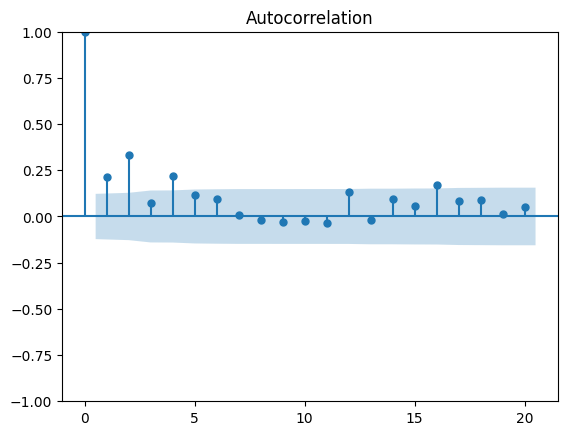

In [37]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(hsample['residu'], lags=20)
plt.show()

<Figure size 1000x500 with 0 Axes>

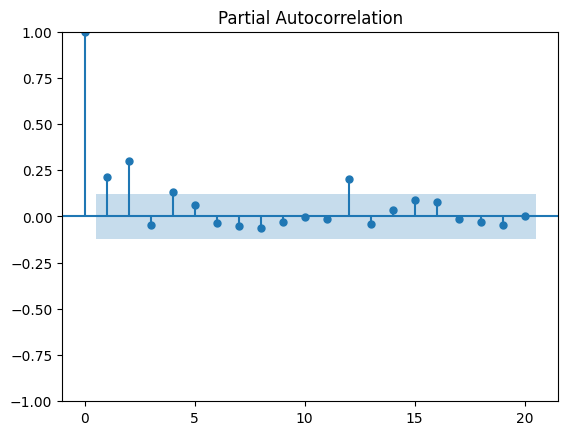

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_pacf(hsample['residu'], lags=20, method='ywm')
plt.show()


In [39]:
hsample.groupby("horizon")["residu"].mean()

horizon
7      -1.155607
8      96.018644
11   -131.938167
12    106.857001
Name: residu, dtype: float64

In [46]:
from lightgbm import LGBMRegressor

def train_layer3_lgbm(l3_train: pd.DataFrame, l3_val: pd.DataFrame | None = None):
    feature_cols = [
        "is_holiday","is_pre_holiday","is_post_holiday",
        "iso_week", "month",
        "std_10","cv_10", "mean_10",
        "y_struct",
    ]
    for extra in ["raw_ratio","clipped_ratio","prophet_yhat"]:
        if extra in l3_train.columns:
            feature_cols.append(extra)

    X_tr = l3_train[feature_cols].fillna(0)
    y_tr = l3_train["target_log_ratio"].astype(float)

    # Recency weights (by cutoff_date)
    last_cutoff = l3_train["cutoff_date"].max()
    age_days = (last_cutoff - l3_train["cutoff_date"]).dt.days.clip(lower=0).astype(float)
    w_tr = 0.5 ** (age_days / 60.0)

    model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.01,
        num_leaves=40,
        subsample=0.6,
        colsample_bytree=0.8,
        random_state=42
    )

    if l3_val is not None and len(l3_val) > 0:
        X_va = l3_val[feature_cols].fillna(0)
        y_va = l3_val["target_log_ratio"].astype(float)
        model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], eval_metric="l2")
    else:
        model.fit(X_tr, y_tr, sample_weight=w_tr)

    return model, feature_cols

l3_model, l3_features = train_layer3_lgbm(l3_train, l3_val)
len(l3_features)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1287
[LightGBM] [Info] Number of data points in the train set: 1024, number of used features: 12
[LightGBM] [Info] Start training from score 0.062905
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


12

In [47]:
def apply_layer3(tbl: pd.DataFrame, l3_model, l3_features):
    X = tbl[l3_features].fillna(0)
    delta = l3_model.predict(X)
    out = tbl.copy()
    out["l3_log_ratio_pred"] = delta
    out["y_pred_l3"] = out["y_struct"] * np.exp(out["l3_log_ratio_pred"])
    return out

val_out = apply_layer3(l3_val, l3_model, l3_features)
val_out[["warehouse_day","y_true","y_struct","y_pred_l3","horizon","l3_log_ratio_pred"]].head()


,warehouse_day,y_true,y_struct,y_pred_l3,horizon,l3_log_ratio_pred
1888,2025-10-02,2585.0,1952.562336,2166.736842,7,0.104080
1889,2025-10-03,2029.0,1959.335788,2032.725404,8,0.036772
1890,2025-10-06,1913.0,1989.891853,2305.334277,11,0.147145
1891,2025-10-07,2727.0,2002.830415,2068.983623,12,0.032496
1892,2025-10-08,1821.0,2016.717143,2383.675473,13,0.167173


In [48]:
# Structural-only preds
pred_struct = val_out.rename(columns={"y_struct":"y_pred"})[["cutoff_date","warehouse_day","y_true","y_pred"]].copy()
pred_struct["model"] = "struct_only"

# Structural + L3 preds
pred_l3 = val_out.rename(columns={"y_pred_l3":"y_pred"})[["cutoff_date","warehouse_day","y_true","y_pred"]].copy()
pred_l3["model"] = "struct_plus_L3"

wk_val = weekly_metrics_table_stacked(pd.concat([pred_struct, pred_l3], ignore_index=True))
summarize_weekly_by_model(wk_val)


/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_11880/2340275692.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return wk.groupby("model", as_index=False).apply(_summ).reset_index(drop=True)


,model,median_abs_error,p90_abs_error,median_mape,p90_mape,median_smape,under_forecast_rate,bias_mean,bias_median,error_std,n_weeks
0,struct_only,127.027822,290.089022,0.075925,0.146591,0.076368,0.384615,6.515871,78.797062,185.459075,13.0
1,struct_plus_L3,108.462313,306.308725,0.101455,0.157222,0.108313,0.615385,-46.754871,-101.883969,206.575182,13.0


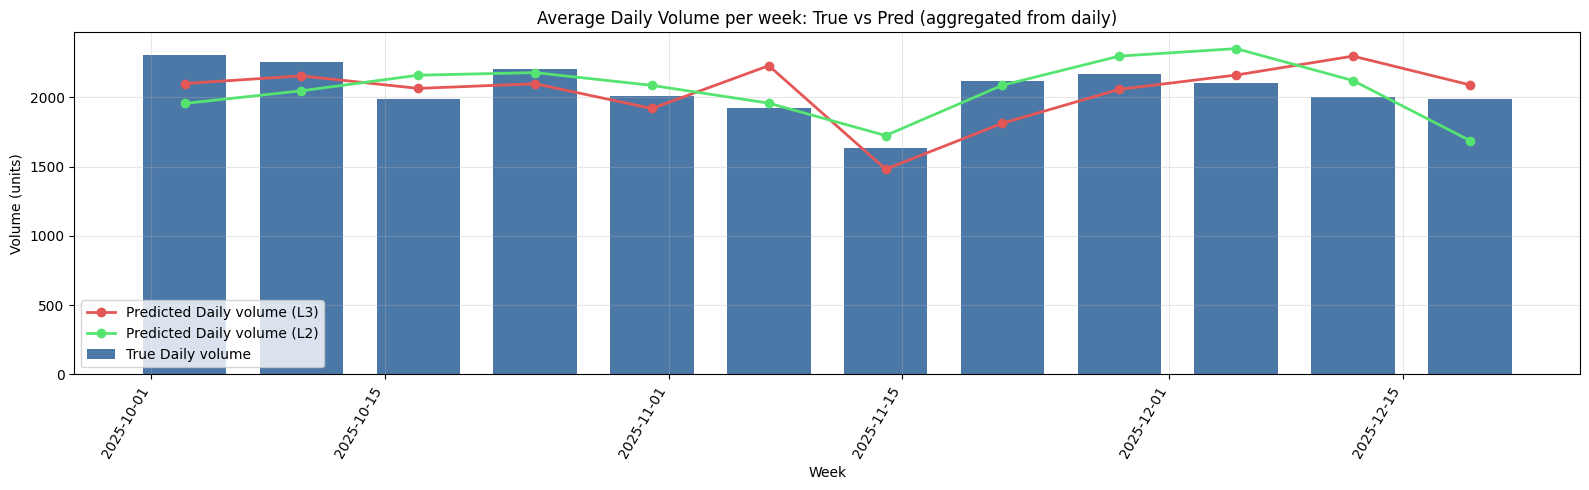

In [49]:

import pandas as pd
import matplotlib.pyplot as plt

# df has columns: warehouse_day, y_true, y_pred_l3
df2 = val_out.copy()  # replace df with your actual variable name
df2["warehouse_day"] = pd.to_datetime(df2["warehouse_day"])

# --- Aggregate to weekly ---
# Choose how to aggregate: 'sum' (volume) or 'mean' (average). Using sum here.
weekly = (
    df2
    .set_index("warehouse_day")
    .resample("W-FRI")  # weekly periods ending on Monday; adjust if needed (e.g., 'W-SUN')
    .agg({"y_true": "mean", "y_pred_l3": "mean", "y_struct": "mean"})
    .reset_index()
    .rename(columns={"warehouse_day": "week"})
)

# --- Plot: bars for true, line for pred ---
plt.figure(figsize=(16,5))

# Bars = true weekly values
plt.bar(
    weekly["week"].iloc[:-1],
    weekly["y_true"].iloc[:-1],
    width=5,                     # visual width for weekly bars
    label="True Daily volume",
    color="#4C78A8"
)

# Line = predicted weekly values
plt.plot(
    weekly["week"].iloc[:-1],
    weekly["y_pred_l3"].iloc[:-1],
    label="Predicted Daily volume (L3)",
    color="#E45756",
    linewidth=2,
    marker="o"
)
plt.plot(
    weekly["week"].iloc[:-1],
    weekly["y_struct"].iloc[:-1],
    label="Predicted Daily volume (L2)",
    color="#56E470",
    linewidth=2,
    marker="o"
)

plt.title("Average Daily Volume per week: True vs Pred (aggregated from daily)")
plt.xlabel("Week")
plt.ylabel("Volume (units)")
plt.xticks(rotation=60, ha="right")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


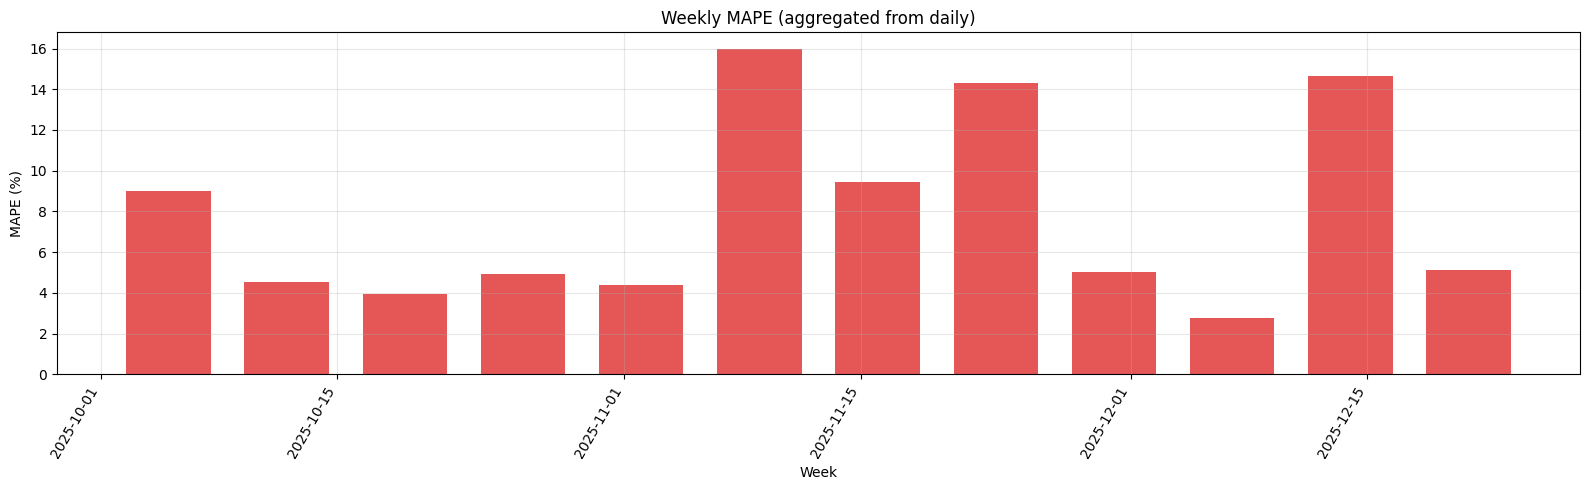

In [50]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df2 = val_out.copy()  # replace df with your actual variable name
df2["warehouse_day"] = pd.to_datetime(df2["warehouse_day"])

# Weekly aggregation (sum of true + pred)
weekly = (
    df2.set_index("warehouse_day")
       .resample("W-SUN")   # weeks ending Sunday (modify if needed)
       .agg({"y_true": "sum", "y_pred_l3": "sum"})
       .reset_index()
       .rename(columns={"warehouse_day": "week"})
)

# Compute weekly MAPE
weekly["mape"] = np.abs((weekly["y_true"] - weekly["y_pred_l3"]) / weekly["y_true"]) * 100
weekly["mae"] = np.abs((weekly["y_true"] - weekly["y_pred_l3"]))

# Plot
plt.figure(figsize=(16,5))
plt.bar(
    weekly["week"].iloc[:-1],
    weekly["mape"].iloc[:-1],
    color="#E45756",
    width=5
)

plt.title("Weekly MAPE (aggregated from daily)")
plt.xlabel("Week")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=60, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [51]:
weekly

,week,y_true,y_pred_l3,mape,mae
0,2025-10-05,4614.0,4199.462246,8.984347,414.537754
1,2025-10-12,15797.0,15083.812214,4.514704,713.187786
2,2025-10-19,23838.0,24774.345694,3.927954,936.345694
3,2025-10-26,35298.0,33567.093601,4.903695,1730.906399
4,2025-11-02,32120.0,30711.595347,4.384821,1408.404653
5,2025-11-09,30742.0,35659.353629,15.995555,4917.353629
6,2025-11-16,26175.0,23700.772070,9.452638,2474.227930
7,2025-11-23,33840.0,29004.716508,14.288663,4835.283492
8,2025-11-30,34659.0,32923.602993,5.007060,1735.397007
9,2025-12-07,33649.0,34573.455873,2.747350,924.455873


In [52]:
weekly["mape"].iloc[:-1].mean()

np.float64(7.827945819393272)

In [53]:
weekly["mape"].iloc[:-1].quantile(0.75)

np.float64(10.66164401086316)

In [54]:

import numpy as np
import pandas as pd

# --- Input prep ---
gdf = val_out.copy()

# Coerce types
gdf['horizon'] = pd.to_numeric(gdf['horizon'], errors='coerce').astype('Int64')
if not np.issubdtype(gdf['warehouse_day'].dtype, np.datetime64):
    gdf['warehouse_day'] = pd.to_datetime(gdf['warehouse_day'], errors='coerce')

# Keep horizons in your range and valid data
gdf = gdf[gdf['horizon'].between(7, 27)].dropna(subset=['y_true', 'y_pred_l3'])

# --- Keep only weekday horizons in each 7-day cycle: 7-11, 14-18, 21-25, 28-32, ...
weekday_mask = ((gdf['horizon'] - 7) % 7) <= 4  # keep first 5 days of each 7-day block
gdf = gdf[weekday_mask]

# --- Bucket into forecast weeks (wk1 = 7-11, wk2 = 14-18, wk3 = 21-25, wk4 = 28-32, ...)
gdf['forecast_week_idx'] = ((gdf['horizon'] - 7) // 7 + 1).astype(int)

# Human-readable labels
h_max = int(gdf['horizon'].max()) if len(gdf) else 27
def week_label(idx, hmax=h_max):
    start = 7 + (idx - 1) * 7
    end   = min(start + 4, hmax)  # only 5 weekdays
    return f"Week {idx} ({start}–{end})"
gdf['forecast_week'] = gdf['forecast_week_idx'].map(week_label)

# --- Errors ---
gdf['abs_err'] = (gdf['y_true'] - gdf['y_pred_l3']).abs()
gdf['ape'] = gdf['abs_err'] / gdf['y_true'].replace(0, np.nan)  # NaN when y_true == 0 -> excluded from mean
# Optional: SMAPE if you have many small/zero y_true
# gdf['smape'] = gdf['abs_err'] / ((gdf['y_true'].abs() + gdf['y_pred_l3'].abs()) / 2)

# --- 1) Overall accuracy per forecast week ---
fw_summary = (
    gdf.groupby(['forecast_week_idx', 'forecast_week'])
       .agg(
           n_obs=('horizon', 'size'),
           MAE=('abs_err', 'mean'),
           MAPE=('ape', 'mean'),
           # SMAPE=('smape', 'mean'),
       )
       .reset_index()
       .sort_values('forecast_week_idx')
)
fw_summary['MAPE_pct'] = fw_summary['MAPE'] * 100

# --- 2) (Optional) Accuracy per calendar week × forecast week ---
iso = gdf['warehouse_day'].dt.isocalendar()
gdf['iso_year'] = iso['year'].astype(int)
gdf['iso_week'] = iso['week'].astype(int)

weekly_fw_summary = (
    gdf.groupby(['iso_year', 'iso_week', 'forecast_week_idx', 'forecast_week'])
       .agg(
           n_days=('warehouse_day', 'nunique'),
           MAE=('abs_err', 'mean'),
           MAPE=('ape', 'mean'),
           # SMAPE=('smape', 'mean'),
       )
       .reset_index()
       .sort_values(['iso_year', 'iso_week', 'forecast_week_idx'])
)
weekly_fw_summary['MAPE_pct'] = weekly_fw_summary['MAPE'] * 100

# --- 3) (Optional) Pivot for a quick matrix view across calendar weeks ---
weekly_key = weekly_fw_summary.assign(
    iso_week_key=lambda d: d['iso_year'].astype(str) + '-W' + d['iso_week'].astype(str).str.zfill(2)
)
pivot_mape = weekly_key.pivot_table(index='iso_week_key', columns='forecast_week', values='MAPE_pct', aggfunc='mean')
pivot_mae  = weekly_key.pivot_table(index='iso_week_key', columns='forecast_week', values='MAE', aggfunc='mean')

print("\n=== Overall by forecast week ===")
print(fw_summary[['forecast_week', 'n_obs', 'MAE', 'MAPE', 'MAPE_pct']])

print("\n=== Weekly × forecast week (head) ===")
print(weekly_fw_summary[['iso_year', 'iso_week', 'forecast_week', 'n_days', 'MAE', 'MAPE', 'MAPE_pct']].head())

print("\n=== Pivot MAPE% (head) ===")
print(pivot_mape.head())



=== Overall by forecast week ===
    forecast_week  n_obs         MAE      MAPE   MAPE_pct
0   Week 1 (7–11)     30  249.322033  0.127214  12.721413
1  Week 2 (14–18)     30  248.780390  0.129489  12.948897
2  Week 3 (21–25)     30  252.105656  0.134464  13.446441

=== Weekly × forecast week (head) ===
   iso_year  iso_week   forecast_week  n_days         MAE      MAPE   MAPE_pct
0      2025        40   Week 1 (7–11)       2  210.994281  0.081820   8.182000
1      2025        41   Week 1 (7–11)       3  343.711000  0.159685  15.968533
2      2025        41  Week 2 (14–18)       2  185.691219  0.079777   7.977742
3      2025        42   Week 1 (7–11)       3  198.331825  0.113109  11.310885
4      2025        42  Week 2 (14–18)       3  189.253866  0.106915  10.691485

=== Pivot MAPE% (head) ===
forecast_week  Week 1 (7–11)  Week 2 (14–18)  Week 3 (21–25)
iso_week_key                                                
2025-W40            8.182000             NaN             NaN
2025-W41  

In [55]:
pivot_mape

forecast_week,Week 1 (7–11),Week 2 (14–18),Week 3 (21–25)
iso_week_key,,,
2025-W40,8.182000,NaN,NaN
2025-W41,15.968533,7.977742,NaN
2025-W42,11.310885,10.691485,6.030670
2025-W43,10.073703,11.062458,8.885732
2025-W44,10.769485,7.198026,6.544728
2025-W45,26.054868,24.878386,27.475622
2025-W46,3.924669,5.940479,5.610700
2025-W47,13.767065,11.811853,17.505290
2025-W48,6.824698,8.709452,8.632191


In [56]:
weekly_fw_summary

,iso_year,iso_week,forecast_week_idx,forecast_week,n_days,MAE,MAPE,MAPE_pct
0,2025,40,1,Week 1 (7–11),2,210.994281,0.081820,8.182000
1,2025,41,1,Week 1 (7–11),3,343.711000,0.159685,15.968533
2,2025,41,2,Week 2 (14–18),2,185.691219,0.079777,7.977742
3,2025,42,1,Week 1 (7–11),3,198.331825,0.113109,11.310885
4,2025,42,2,Week 2 (14–18),3,189.253866,0.106915,10.691485
5,2025,42,3,Week 3 (21–25),2,120.886848,0.060307,6.030670
6,2025,43,1,Week 1 (7–11),3,242.847067,0.100737,10.073703
7,2025,43,2,Week 2 (14–18),3,271.642242,0.110625,11.062458
8,2025,43,3,Week 3 (21–25),3,214.878599,0.088857,8.885732
9,2025,44,1,Week 1 (7–11),3,205.596479,0.107695,10.769485


In [57]:
pivot_mape["Week 1 (7–11)"].mean()

np.float64(11.97151070432656)

In [58]:
pivot_mae["Week 1 (7–11)"].mean()

np.float64(236.849833626463)

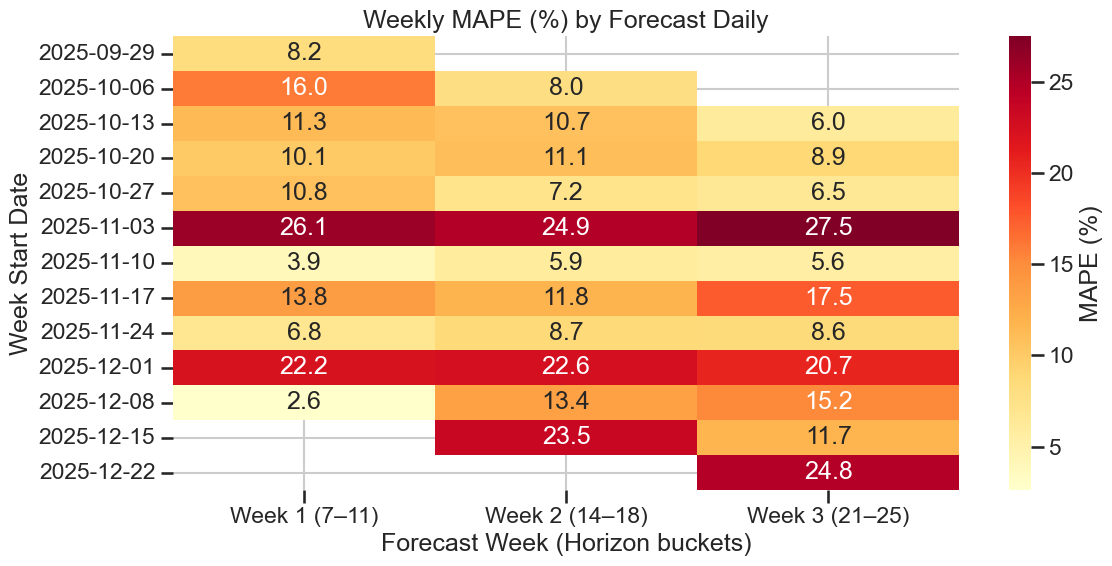

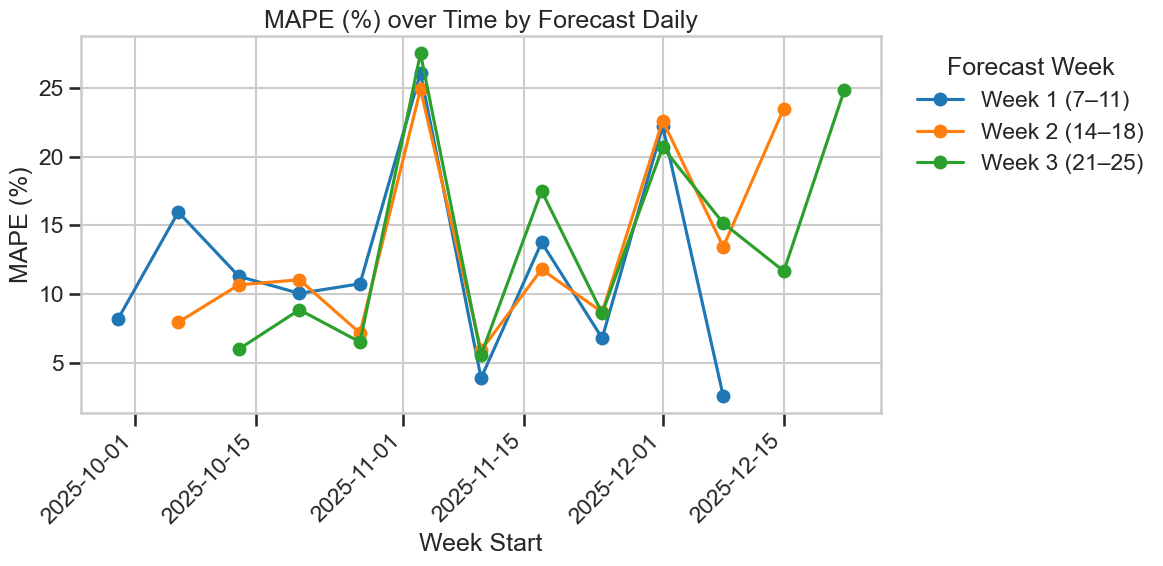

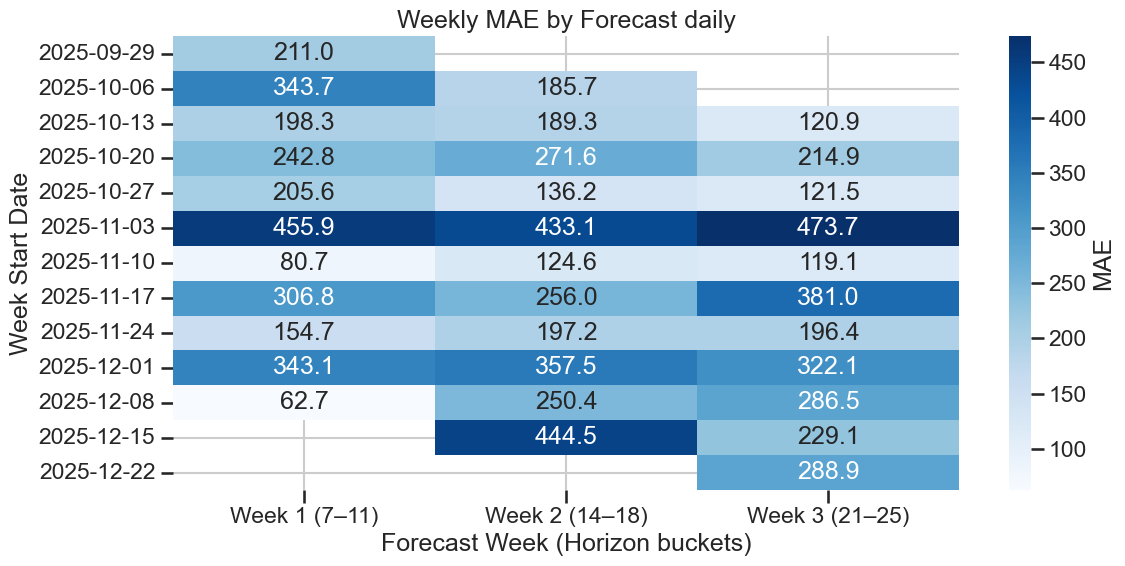

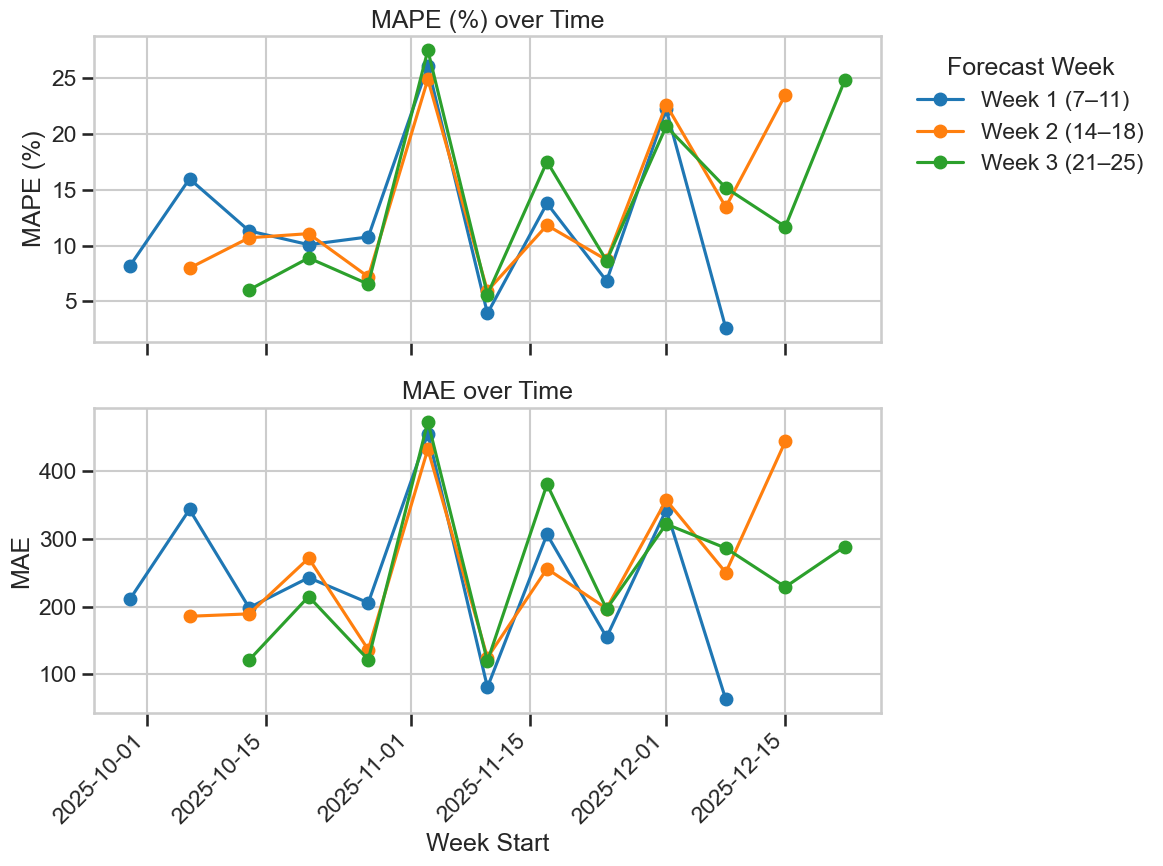

In [59]:

# -*- coding: utf-8 -*-
"""
Weekly plots of MAE/MAPE by forecast-week buckets (Week 1: 7–11, Week 2: 14–18, Week 3: 21–25, Week 4: 28–(≤28))

INPUT: DataFrame df with columns:
- warehouse_day: date per day
- y_true: actuals
- y_pred_l3: predictions
- horizon: lead time (integer). We keep weekday horizons only: 7–11, 14–18, 21–25, 28–32 (truncated to 28).

OUTPUT: Four plots shown inline (heatmaps and line charts) with x/y axes in DATE, not week numbers.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter, AutoDateLocator

# ----------------------------- STYLE ---------------------------------
plt.ioff()  # turn off interactive pop-ups if running as a script; remove in notebooks if desired
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# ----------------------------- PIPELINE --------------------------------
# 1) Validate & prepare input
if 'df' not in globals():
    raise RuntimeError("This script expects a DataFrame named `df` in the global scope.")

gdf = val_out.copy()

# Types
gdf['horizon'] = pd.to_numeric(gdf['horizon'], errors='coerce').astype('Int64')
if not np.issubdtype(gdf['warehouse_day'].dtype, np.datetime64):
    gdf['warehouse_day'] = pd.to_datetime(gdf['warehouse_day'], errors='coerce')

# Keep valid horizons (7..28) and non-missing rows
gdf = gdf[gdf['horizon'].between(7, 27)].dropna(subset=['y_true', 'y_pred_l3', 'warehouse_day'])

# Keep ONLY weekday horizons inside each 7-day cycle: 7–11, 14–18, 21–25, 28–32 (→ 28)
weekday_mask = ((gdf['horizon'] - 7) % 7) <= 4  # offsets 0..4 are Mon–Fri
gdf = gdf[weekday_mask]

# Forecast-week bucket index & label
gdf['forecast_week_idx'] = ((gdf['horizon'] - 7) // 7 + 1).astype(int)
h_max = int(gdf['horizon'].max()) if len(gdf) else 28
def fw_label(idx, hmax=h_max):
    start = 7 + (idx - 1) * 7
    end   = min(start + 4, hmax)  # 5 weekdays only
    return f"Week {idx} ({start}–{end})"
gdf['forecast_week'] = gdf['forecast_week_idx'].map(fw_label)

# Daily errors
gdf['abs_err'] = (gdf['y_true'] - gdf['y_pred_l3']).abs()
gdf['ape'] = gdf['abs_err'] / gdf['y_true'].replace(0, np.nan)  # MAPE avoids y_true==0
# Optional: SMAPE if many zeros/small values; uncomment lines below if needed
# gdf['smape'] = gdf['abs_err'] / ((gdf['y_true'].abs() + gdf['y_pred_l3'].abs()) / 2)

# Week start date (Monday) for each warehouse_day
gdf['week_start'] = gdf['warehouse_day'] - pd.to_timedelta(gdf['warehouse_day'].dt.dayofweek, unit='D')
# Optional: week_end (unused in plots but handy for labels)
# gdf['week_end'] = gdf['week_start'] + pd.Timedelta(days=6)

# Weekly averages by forecast-week bucket (DATE-based)
weekly_fw_summary = (
    gdf.groupby(['week_start', 'forecast_week_idx', 'forecast_week'])
       .agg(
           n_days=('warehouse_day', 'nunique'),  # #days contributing to that (week_start, bucket)
           MAE=('abs_err', 'mean'),
           MAPE=('ape', 'mean'),
           # SMAPE=('smape', 'mean'),  # if enabled
       )
       .reset_index()
       .sort_values(['week_start', 'forecast_week_idx'])
)
weekly_fw_summary['MAPE_pct'] = (weekly_fw_summary['MAPE'] * 100)

# Pivots (rows = week_start DATE)
pivot_mape = weekly_fw_summary.pivot_table(index='week_start', columns='forecast_week', values='MAPE_pct', aggfunc='mean')
pivot_mae  = weekly_fw_summary.pivot_table(index='week_start', columns='forecast_week', values='MAE',      aggfunc='mean')

# Ensure chronological order
pivot_mape = pivot_mape.sort_index()
pivot_mae  = pivot_mae.sort_index()

# ----------------------------- PLOTTING --------------------------------
def _format_date_axis(ax, fmt='%Y-%m-%d', rotation=45):
    locator = AutoDateLocator(minticks=6, maxticks=12)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(DateFormatter(fmt))
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha('right')

# 1) Heatmap: Weekly MAPE (%) by Forecast Week (y-axis shown as date strings for readability)
disp_mape = pivot_mape.copy()
disp_mape.index = disp_mape.index.strftime('%Y-%m-%d')
fig1, ax1 = plt.subplots(figsize=(12, 6))
sns.heatmap(disp_mape, ax=ax1, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'MAPE (%)'})
ax1.set_title('Weekly MAPE (%) by Forecast Daily')
ax1.set_xlabel('Forecast Week (Horizon buckets)')
ax1.set_ylabel('Week Start Date')
fig1.tight_layout()
plt.show()

# 2) Line chart: MAPE (%) over Time (x-axis = week_start date)
fig2, ax2 = plt.subplots(figsize=(12, 6))
for col in pivot_mape.columns:
    ax2.plot(pivot_mape.index, pivot_mape[col], marker='o', label=col)
ax2.set_title('MAPE (%) over Time by Forecast Daily')
ax2.set_xlabel('Week Start')
ax2.set_ylabel('MAPE (%)')
ax2.legend(title='Forecast Week', bbox_to_anchor=(1.02, 1), loc='upper left')
_format_date_axis(ax2)
fig2.tight_layout()
plt.show()

# 3) Heatmap: Weekly MAE by Forecast Week (y-axis shown as date strings)
disp_mae = pivot_mae.copy()
disp_mae.index = disp_mae.index.strftime('%Y-%m-%d')
fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.heatmap(disp_mae, ax=ax3, cmap='Blues', annot=True, fmt='.1f', cbar_kws={'label': 'MAE'})
ax3.set_title('Weekly MAE by Forecast daily')
ax3.set_xlabel('Forecast Week (Horizon buckets)')
ax3.set_ylabel('Week Start Date')
fig3.tight_layout()
plt.show()

# 4) Dual panels: MAPE (%) and MAE over Time (x-axis = week_start date)
fig4, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)

# Top: MAPE lines
for col in pivot_mape.columns:
    axes[0].plot(pivot_mape.index, pivot_mape[col], marker='o', label=col)
axes[0].set_title('MAPE (%) over Time')
axes[0].set_ylabel('MAPE (%)')
axes[0].legend(title='Forecast Week', bbox_to_anchor=(1.02, 1), loc='upper left')
_format_date_axis(axes[0])

# Bottom: MAE lines
for col in pivot_mae.columns:
    axes[1].plot(pivot_mae.index, pivot_mae[col], marker='o', label=col)
axes[1].set_title('MAE over Time')
axes[1].set_xlabel('Week Start')
axes[1].set_ylabel('MAE')
_format_date_axis(axes[1])

fig4.tight_layout()
plt.show()



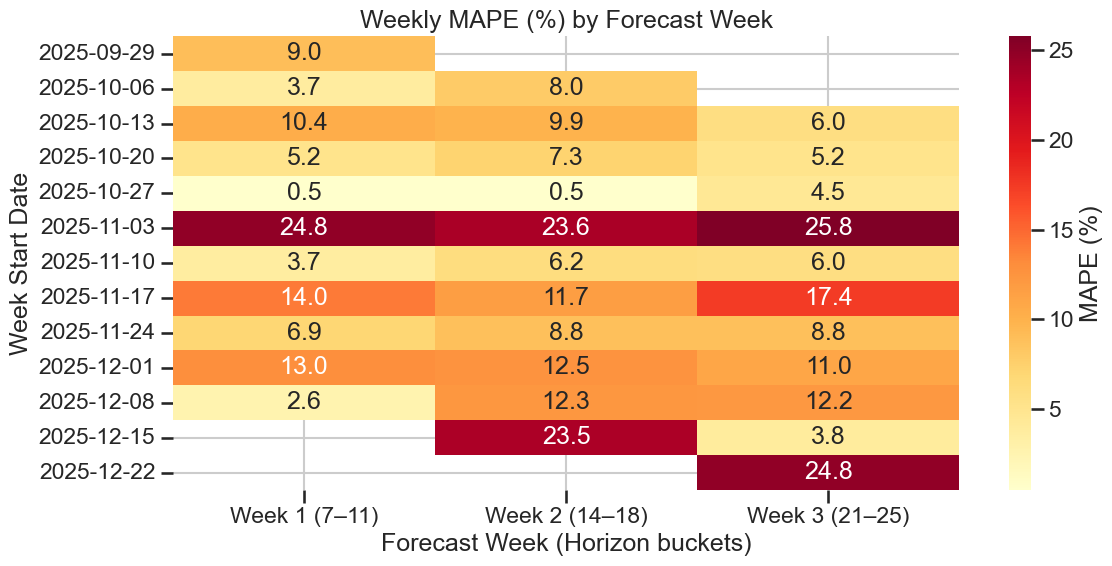

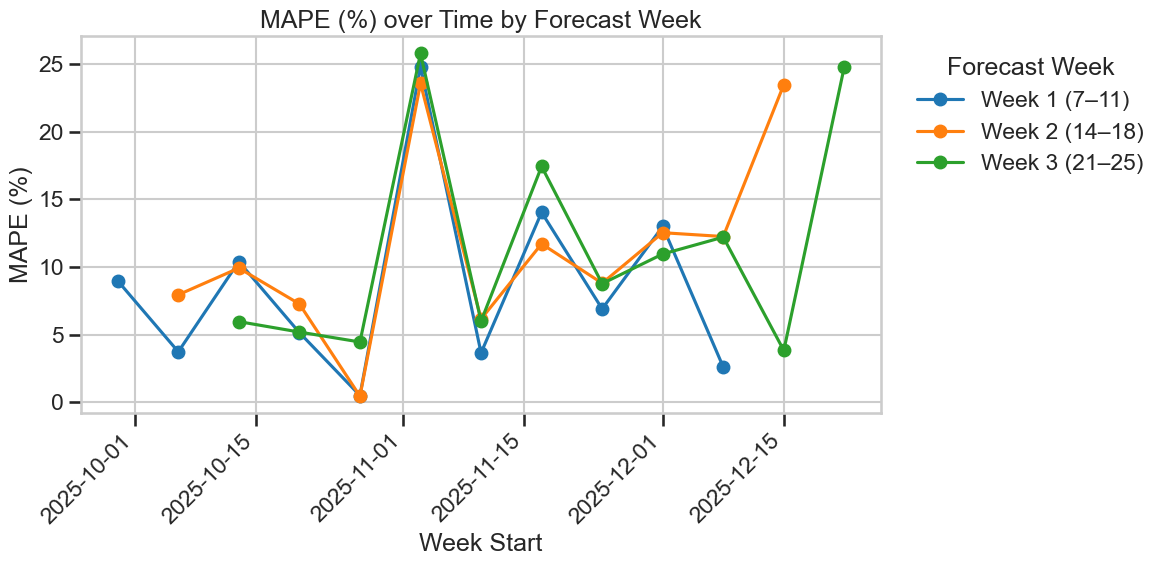

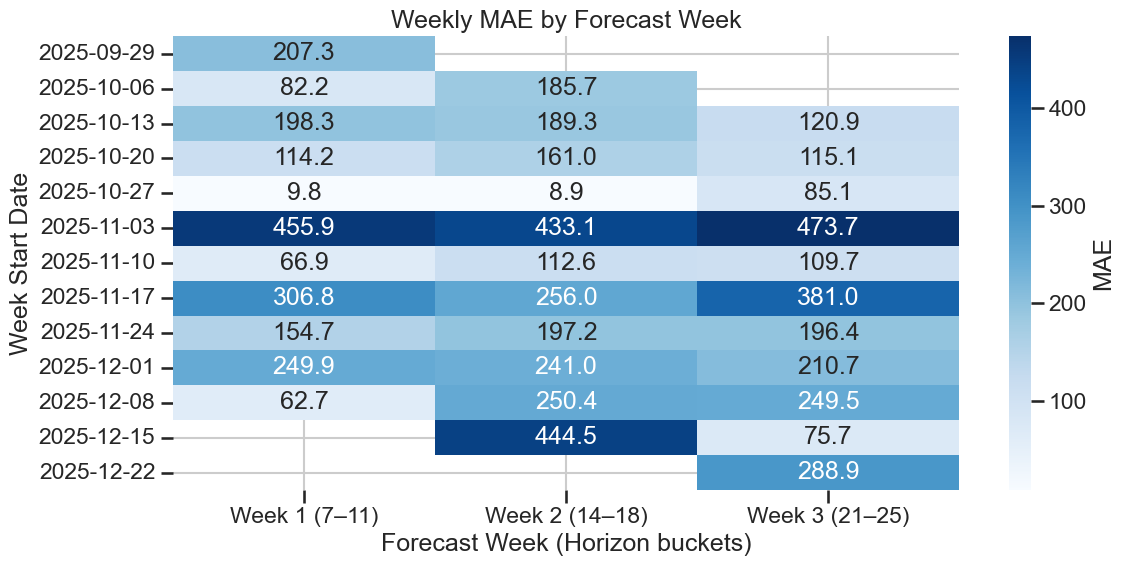

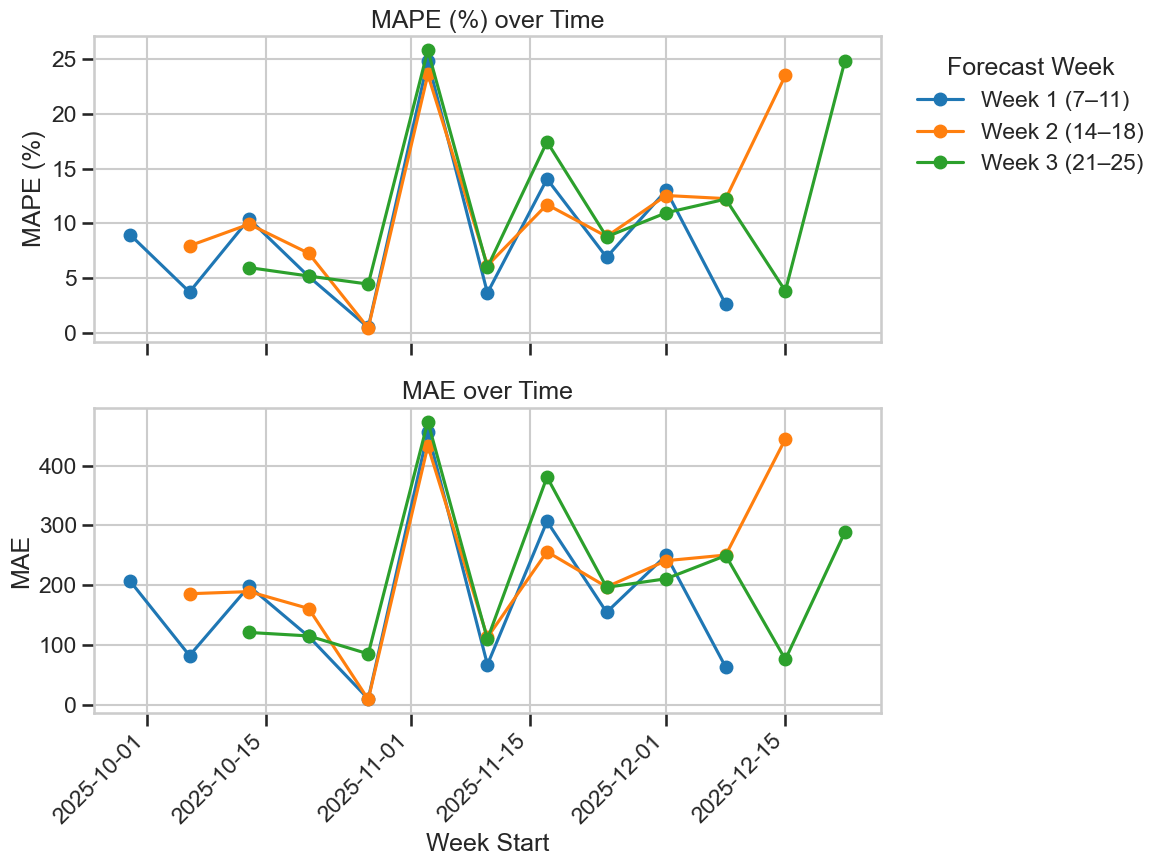

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter, AutoDateLocator

# ----------------------------- STYLE ---------------------------------
plt.ioff()  # turn off interactive pop-ups if running as a script; remove in notebooks if desired
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# ----------------------------- PIPELINE --------------------------------
# 1) Validate & prepare input
if 'df' not in globals():
    raise RuntimeError("This script expects a DataFrame named `df` in the global scope.")

gdf = val_out.copy()

# Types
gdf['horizon'] = pd.to_numeric(gdf['horizon'], errors='coerce').astype('Int64')
if not np.issubdtype(gdf['warehouse_day'].dtype, np.datetime64):
    gdf['warehouse_day'] = pd.to_datetime(gdf['warehouse_day'], errors='coerce')

# Keep valid horizons (7..28) and non-missing rows
gdf = gdf[gdf['horizon'].between(7, 27)].dropna(subset=['y_true', 'y_pred_l3', 'warehouse_day'])

# Keep ONLY weekday horizons inside each 7-day cycle: 7–11, 14–18, 21–25
weekday_mask = ((gdf['horizon'] - 7) % 7) <= 4  # offsets 0..4 are Mon–Fri
gdf = gdf[weekday_mask]

# Forecast-week bucket index & label
gdf['forecast_week_idx'] = ((gdf['horizon'] - 7) // 7 + 1).astype(int)
h_max = int(gdf['horizon'].max()) if len(gdf) else 28
def fw_label(idx, hmax=h_max):
    start = 7 + (idx - 1) * 7
    end   = min(start + 4, hmax)  # 5 weekdays only
    return f"Week {idx} ({start}–{end})"
gdf['forecast_week'] = gdf['forecast_week_idx'].map(fw_label)

# Daily errors
gdf['abs_err'] = (gdf['y_true'] - gdf['y_pred_l3']).abs()
gdf['ape'] = gdf['abs_err'] / gdf['y_true'].replace(0, np.nan)  # MAPE avoids y_true==0


# Week start date (Monday) for each warehouse_day
gdf['week_start'] = gdf['warehouse_day'] - pd.to_timedelta(gdf['warehouse_day'].dt.dayofweek, unit='D')


# Weekly averages by forecast-week bucket (DATE-based)
weekly_fw_summary = (
    gdf.groupby(['week_start', 'forecast_week_idx', 'forecast_week'])
       .agg(
           n_days=('warehouse_day', 'nunique'),  # #days contributing to that (week_start, bucket)
           MAE=('abs_err', 'mean'),
           MAPE=('ape', 'mean'),
           week_p=("y_pred_l3","mean"),
           week_t=("y_true","mean")
           # SMAPE=('smape', 'mean'),  # if enabled
       )
       .reset_index()
       .sort_values(['week_start', 'forecast_week_idx'])
)
weekly_fw_summary['MAPE_pct'] = (weekly_fw_summary['MAPE'] * 100)
weekly_fw_summary['MAPE_w'] = (abs(weekly_fw_summary['week_t']- weekly_fw_summary['week_p'])/ weekly_fw_summary['week_t'].replace(0, np.nan) * 100)
weekly_fw_summary['MAE_w'] = abs(weekly_fw_summary['week_t']- weekly_fw_summary['week_p'])



# Pivots (rows = week_start DATE)
pivot_mape = weekly_fw_summary.pivot_table(index='week_start', columns='forecast_week', values='MAPE_w', aggfunc='mean')
pivot_mae  = weekly_fw_summary.pivot_table(index='week_start', columns='forecast_week', values='MAE_w',      aggfunc='mean')

# Ensure chronological order
pivot_mape = pivot_mape.sort_index()
pivot_mae  = pivot_mae.sort_index()

# ----------------------------- PLOTTING --------------------------------
def _format_date_axis(ax, fmt='%Y-%m-%d', rotation=45):
    locator = AutoDateLocator(minticks=6, maxticks=12)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(DateFormatter(fmt))
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha('right')

# 1) Heatmap: Weekly MAPE (%) by Forecast Week (y-axis shown as date strings for readability)
disp_mape = pivot_mape.copy()
disp_mape.index = disp_mape.index.strftime('%Y-%m-%d')
fig1, ax1 = plt.subplots(figsize=(12, 6))
sns.heatmap(disp_mape, ax=ax1, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'MAPE (%)'})
ax1.set_title('Weekly MAPE (%) by Forecast Week')
ax1.set_xlabel('Forecast Week (Horizon buckets)')
ax1.set_ylabel('Week Start Date')
fig1.tight_layout()
plt.show()

# 2) Line chart: MAPE (%) over Time (x-axis = week_start date)
fig2, ax2 = plt.subplots(figsize=(12, 6))
for col in pivot_mape.columns:
    ax2.plot(pivot_mape.index, pivot_mape[col], marker='o', label=col)
ax2.set_title('MAPE (%) over Time by Forecast Week')
ax2.set_xlabel('Week Start')
ax2.set_ylabel('MAPE (%)')
ax2.legend(title='Forecast Week', bbox_to_anchor=(1.02, 1), loc='upper left')
_format_date_axis(ax2)
fig2.tight_layout()
plt.show()

# 3) Heatmap: Weekly MAE by Forecast Week (y-axis shown as date strings)
disp_mae = pivot_mae.copy()
disp_mae.index = disp_mae.index.strftime('%Y-%m-%d')
fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.heatmap(disp_mae, ax=ax3, cmap='Blues', annot=True, fmt='.1f', cbar_kws={'label': 'MAE'})
ax3.set_title('Weekly MAE by Forecast Week')
ax3.set_xlabel('Forecast Week (Horizon buckets)')
ax3.set_ylabel('Week Start Date')
fig3.tight_layout()
plt.show()

# 4) Dual panels: MAPE (%) and MAE over Time (x-axis = week_start date)
fig4, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)

# Top: MAPE lines
for col in pivot_mape.columns:
    axes[0].plot(pivot_mape.index, pivot_mape[col], marker='o', label=col)
axes[0].set_title('MAPE (%) over Time')
axes[0].set_ylabel('MAPE (%)')
axes[0].legend(title='Forecast Week', bbox_to_anchor=(1.02, 1), loc='upper left')
_format_date_axis(axes[0])

# Bottom: MAE lines
for col in pivot_mae.columns:
    axes[1].plot(pivot_mae.index, pivot_mae[col], marker='o', label=col)
axes[1].set_title('MAE over Time')
axes[1].set_xlabel('Week Start')
axes[1].set_ylabel('MAE')
_format_date_axis(axes[1])

fig4.tight_layout()
plt.show()

